In [13]:
import pyodbc
import pandas as pd
import numpy as np

print(pyodbc.drivers())

['SQL Server', 'SQL Server Native Client 11.0', 'B1CRHPROXY', 'ODBC Driver 13 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)', 'ODBC Driver 18 for SQL Server', 'SQL Server Native Client RDA 11.0', 'ODBC Driver 17 for SQL Server']


In [14]:
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
from dotenv import load_dotenv
import os
import pyodbc

load_dotenv()

SERVER = os.getenv("DB_SERVER1")
DBNAME = os.getenv("DB_NAME1")
USER = os.getenv("DB_USER1")
PASS = os.getenv("DB_PASSWORD1")
ENCRYPT = os.getenv("DB_ENCRYPT", "yes")
TRUST = os.getenv("DB_TRUST_CERT", "yes")

SERVER = SERVER.replace("\\\\", "\\")  # normaliza


cnx = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={SERVER};"
    f"DATABASE={DBNAME};"
    f"UID={USER};"
    f"PWD={PASS};"
    f"Encrypt={ENCRYPT};TrustServerCertificate={TRUST};"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={quote_plus(cnx)}")

In [15]:
from sqlalchemy import text
try:
    with engine.connect() as conn:
        print("Ping:", conn.execute(text("SELECT 1")).scalar_one())
        print("Version:", conn.execute(text("SELECT @@VERSION")).scalar_one())
        print("✅ Conexión OK")
except Exception as e:
    print("❌ Error al conectar:", e)

Ping: 1
Version: Microsoft SQL Server 2017 (RTM) - 14.0.1000.169 (X64) 
	Aug 22 2017 17:04:49 
	Copyright (C) 2017 Microsoft Corporation
	Standard Edition (64-bit) on Windows Server 2019 Standard 10.0 <X64> (Build 17763: )

✅ Conexión OK


Indentifiacr los fabricantes correctos

In [16]:
query_fabricantes="""SELECT
    OMRC.FirmCode AS codigo_fabricante,
    OMRC.FirmName AS marca_fabricante,
    COUNT(OITM.ItemCode) AS cantidad_articulos
FROM OITM
LEFT JOIN OMRC 
    ON OITM.FirmCode = OMRC.FirmCode
WHERE OMRC.FirmName IS NOT NULL
  AND LTRIM(RTRIM(OMRC.FirmName)) <> ''
GROUP BY
    OMRC.FirmCode,
    OMRC.FirmName
ORDER BY
    cantidad_articulos DESC,
    OMRC.FirmName;"""

In [17]:
import os

print(os.getcwd())
print(os.path.exists("./Datos/fabricantes_repuestos_cerosa.csv"))

c:\Users\CHOPPE\Desktop\Software Development\Tesis-Master-AI
True


In [18]:
import pandas as pd

ruta_fabricantes = "./Datos/fabricantes_repuestos_cerosa.xlsx"

df_fabricantes = pd.read_excel(
    ruta_fabricantes
)

df_fabricantes.head()

,codigo_fabricante,marca_fabricante,cantidad_articulos,fabricante_stock,meses_objetivo_cobertura
0,21,NTN,3664,True,6.0
1,-1,- Ningún fabricante -,2933,False,NaN
2,39,SIEMENS,2096,True,6.0
3,28,TIMKEN,1794,True,6.0
4,26,SUMITOMO,1731,True,6.0


In [19]:
df_fabricantes.info()

<class 'pandas.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   codigo_fabricante         262 non-null    int64  
 1   marca_fabricante          262 non-null    str    
 2   cantidad_articulos        262 non-null    int64  
 3   fabricante_stock          262 non-null    bool   
 4   meses_objetivo_cobertura  28 non-null     float64
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 10.4 KB


In [20]:
fabricantes_considerados = (
    df_fabricantes.loc[
        df_fabricantes["fabricante_stock"]==True,
        "marca_fabricante"
    ]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)
print(fabricantes_considerados)

['NTN', 'SIEMENS', 'TIMKEN', 'SUMITOMO', 'INA', 'BANDO', 'JASON', 'HABASIT ROCUA', 'DODGE', 'MARTIN', 'PRECISION INC', 'FLEXCO', 'TSUBAKI', 'FAG', 'HABASIT ABT', 'GATES', 'BELTSERVICE', 'MODUTECH', 'MLT', 'MARATHON', 'DRIVE', 'HABASIT BELTING', 'TAPCO', 'FENNER', 'STIEBER', 'YONG LI EUROPE BV', 'SHARDA', 'INO BELT']


In [21]:
from sqlalchemy import text

# Crear condiciones LIKE dinámicas
condiciones_fabricantes = " OR ".join(
    ["TM.FirmName LIKE ?" for _ in fabricantes_considerados]
)

# Crear parámetros como TUPLA, no como lista
params_fabricantes = tuple(
    f"%{fabricante}%"
    for fabricante in fabricantes_considerados
)

In [22]:
print(condiciones_fabricantes)

TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ? OR TM.FirmName LIKE ?


In [23]:
print(params_fabricantes)

('%NTN%', '%SIEMENS%', '%TIMKEN%', '%SUMITOMO%', '%INA%', '%BANDO%', '%JASON%', '%HABASIT ROCUA%', '%DODGE%', '%MARTIN%', '%PRECISION INC%', '%FLEXCO%', '%TSUBAKI%', '%FAG%', '%HABASIT ABT%', '%GATES%', '%BELTSERVICE%', '%MODUTECH%', '%MLT%', '%MARATHON%', '%DRIVE%', '%HABASIT BELTING%', '%TAPCO%', '%FENNER%', '%STIEBER%', '%YONG LI EUROPE BV%', '%SHARDA%', '%INO BELT%')


In [24]:
import pandas as pd
# 🔥 TEST 2: traer datos a pandas
query = "SELECT TOP 10 * FROM OITM"

df = pd.read_sql(query, engine)

df.head(5)

,ItemCode,ItemName,FrgnName,ItmsGrpCod,CstGrpCode,VatGourpSa,CodeBars,VATLiable,PrchseItem,SellItem,...,U_CI_15_Familia,U_CI_16_CaMeHP,U_CI_16_Ratio,U_CI_16_DiEjeSal,U_CI_14_DiExtRoMM,U_CI_14_NoCotCo,U_CI_14_AnchoMM,U_CI_14_SentR,U_CI_14_DiEjeIN,U_CI_14_TiRod
0,"# 111A-30"" X 1.5",NaN,NaN,100,-1,NaN,None,Y,Y,Y,...,None,None,None,None,None,None,None,None,None,None
1,"# 111A-30"" X 1.5""",BANDA TRANSPORTADORA CON ESPUMA Y GUIA,160,106,-1,,None,Y,Y,Y,...,None,None,None,None,None,None,None,None,None,None
2,"# 111A-54"" X 1.5",NaN,NaN,100,-1,NaN,None,Y,Y,Y,...,None,None,None,None,None,None,None,None,None,None
3,"# 111A-54"" X 1.5""",BANDA TRANSPORTADORA CON ESPUMA Y GUIA,160,106,-1,,None,Y,Y,Y,...,None,None,None,None,None,None,None,None,None,None
4,#108GL,BANDA TRANSPORTADORA 2PLY POLYCR57 WHITE PU GL...,160,106,-1,,None,Y,Y,Y,...,None,None,None,None,None,None,None,None,None,None


In [25]:
Query_OITM = """
SELECT
    /* =====================================================
       IDENTIFICACIÓN DEL ARTÍCULO
       ===================================================== */

    T0.ItemCode AS [Código de artículo],
    T0.ItemName AS [Descripción completa],
    TG.ItmsGrpNam AS [Grupo de artículo],
    T0.InvntryUom AS [Unidad de medida de inventario],
    TM.FirmName AS [Marca / Fabricante],


    /* =====================================================
       COMPRAS
       ===================================================== */

    T0.LastPurDat AS [Última fecha de compra],
    T0.LastPurPrc AS [Último precio de compra],


    /* =====================================================
       COSTOS
       ===================================================== */

    TW.AvgPrice AS [Costo promedio],


    /* =====================================================
       INVENTARIO POR BODEGA
       ===================================================== */

    TW.WhsCode AS [Código de bodega],
    TW.OnHand AS [Stock en mano por bodega],
    TW.IsCommited AS [Stock comprometido],
    TW.OnOrder AS [Stock en pedido / tránsito],


    /* =====================================================
       PARÁMETROS DE COMPRA E INVENTARIO
       ===================================================== */

    T0.MinOrdrQty AS [Cantidad mínima de compra],
    TW.MinStock AS [Stock mínimo],
    TW.MaxStock AS [Stock máximo],


    /* =====================================================
       LISTAS DE PRECIO COMO COLUMNAS
       ===================================================== */

    MAX(CASE WHEN TP.PriceList = 11 THEN TP.Price END) AS [Precio lista 11 - Promociones ecommerce],
    MAX(CASE WHEN TP.PriceList = 12 THEN TP.Price END) AS [Precio lista 12 - B2B VIP],
    MAX(CASE WHEN TP.PriceList = 13 THEN TP.Price END) AS [Precio lista 13 - B2C],
    MAX(CASE WHEN TP.PriceList = 14 THEN TP.Price END) AS [Precio lista 14 - B2B estándar]

FROM OITM T0

LEFT JOIN OITB TG
    ON T0.ItmsGrpCod = TG.ItmsGrpCod

LEFT JOIN OMRC TM
    ON T0.FirmCode = TM.FirmCode

INNER JOIN OITW TW
    ON T0.ItemCode = TW.ItemCode

LEFT JOIN ITM1 TP
    ON T0.ItemCode = TP.ItemCode
    AND TP.PriceList IN (11, 12, 13, 14)

WHERE
    T0.SellItem = 'Y'
    AND T0.PrchseItem = 'Y'
    AND T0.InvntItem = 'Y'
    AND T0.validFor = 'Y'
    AND T0.frozenFor = 'N'

    AND TW.WhsCode IN ('11', '14')
    AND TW.OnHand > 0
    AND TM.FirmName LIKE '%SIEMENS%'

GROUP BY
    T0.ItemCode,
    T0.ItemName,
    TG.ItmsGrpNam,
    T0.InvntryUom,
    TM.FirmName,

    T0.LastPurDat,
    T0.LastPurPrc,

    TW.AvgPrice,
    TW.WhsCode,
    TW.OnHand,
    TW.IsCommited,
    TW.OnOrder,

    T0.MinOrdrQty,
    TW.MinStock,
    TW.MaxStock

ORDER BY
    T0.ItemCode;
"""

In [26]:
df_OITM= pd.read_sql(Query_OITM, engine)
df_OITM.info()


<class 'pandas.DataFrame'>
RangeIndex: 387 entries, 0 to 386
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Código de artículo                       387 non-null    str           
 1   Descripción completa                     387 non-null    str           
 2   Grupo de artículo                        387 non-null    str           
 3   Unidad de medida de inventario           387 non-null    str           
 4   Marca / Fabricante                       387 non-null    str           
 5   Última fecha de compra                   387 non-null    datetime64[us]
 6   Último precio de compra                  387 non-null    float64       
 7   Costo promedio                           387 non-null    float64       
 8   Código de bodega                         387 non-null    str           
 9   Stock en mano por bodega                 387 non-null 

In [27]:
ruta_campos_OITM_SAP="./Datos/campos_OITM_SAPB1.csv"
df_OITM.to_csv("articulos_siemens.csv",
    index=False,
    encoding="utf-8-sig",
    sep=";"
)

## Ventas netas mensuales y totales anuales

En este bloque se agregan al query base las ventas históricas de cada artículo desde enero de 2022 hasta la fecha actual.

Las ventas se calculan como venta neta real, considerando facturas de venta en positivo y notas de crédito en negativo. Esto permite descontar devoluciones o ajustes comerciales y obtener una cantidad vendida más representativa.

Las columnas mensuales se generan dinámicamente desde Python, de modo que cada mes aparezca como una columna independiente en el DataFrame final. Además, se agregan columnas de total anual para cada año, incluyendo el año actual aunque todavía no esté cerrado.

Esta información servirá para analizar rotación, comportamiento de demanda, estacionalidad y relación entre inventario disponible y ventas históricas.

In [28]:
from datetime import date
from dateutil.relativedelta import relativedelta

# ============================================================
# CONFIGURACIÓN DE FECHAS
# ============================================================

fecha_fin = date.today()

# ------------------------------------------------------------
# Ventana de visualización del dataframe
# Desde aquí se generan las columnas mensuales visibles:
# Enero_2024, Febrero_2024, ..., mes actual
# ------------------------------------------------------------

fecha_inicio_visual = date(2024, 1, 1)
fecha_inicio_visual_sql = fecha_inicio_visual.strftime("%Y-%m-%d")


# ------------------------------------------------------------
# Ventana de análisis para métricas dinámicas
# Últimos 24 meses hacia atrás desde la fecha actual.
# Esta ventana se usa para:
# - ventas 24m
# - frecuencia de venta mensual
# - frecuencia de compra mensual
# - conteo ventas netas 24m
# - conteo compras netas 24m
# - cantidad clientes 24m
# - parámetros basados en ventas anuales
# ------------------------------------------------------------

fecha_inicio_24m = fecha_fin - relativedelta(months=24)
fecha_inicio_24m_sql = fecha_inicio_24m.strftime("%Y-%m-%d")

periodo_meses_24m = 24


# ------------------------------------------------------------
# Fecha final para SQL
# En SQL normalmente usamos menor que el día siguiente
# para incluir todo el día actual.
# ------------------------------------------------------------

fecha_fin_sql = fecha_fin.strftime("%Y-%m-%d")


# ------------------------------------------------------------
# Período visual en meses
# Solo si necesitas calcular algo sobre toda la ventana visible.
# No usar para métricas de 24 meses.
# ------------------------------------------------------------

periodo_meses_visual = (
    (fecha_fin.year - fecha_inicio_visual.year) * 12
    + (fecha_fin.month - fecha_inicio_visual.month)
    + 1
)

In [29]:
meses_es = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre"
}

In [30]:
# ============================================================
# GENERAR COLUMNAS MENSUALES Y TOTALES ANUALES
# Formato recomendado para PostgreSQL / analytics:
# venta_enero_2024, venta_febrero_2024, ..., venta_diciembre_2024, venta_total_2024
# venta_enero_2025, venta_febrero_2025, ..., venta_diciembre_2025, venta_total_2025
# venta_enero_2026, ..., venta_mes_actual_2026, venta_total_2026
# ============================================================

columnas_ventas_sql = []
columnas_ventas_finales = []

anio_inicio = fecha_inicio_visual.year
anio_fin = fecha_fin.year

for anio in range(anio_inicio, anio_fin + 1):

    for mes in range(1, 13):

        # No generar meses futuros del año actual
        if anio == fecha_fin.year and mes > fecha_fin.month:
            break

        nombre_mes = meses_es[mes].lower()

        # Quitar tildes por seguridad en nombres de columnas SQL
        nombre_mes = (
            nombre_mes
            .replace("á", "a")
            .replace("é", "e")
            .replace("í", "i")
            .replace("ó", "o")
            .replace("ú", "u")
            .replace("ñ", "n")
        )

        nombre_columna = f"venta_{nombre_mes}_{anio}"

        fecha_mes_inicio = f"{anio}-{mes:02d}-01"

        if mes == 12:
            fecha_mes_fin = f"{anio + 1}-01-01"
        else:
            fecha_mes_fin = f"{anio}-{mes + 1:02d}-01"

        columna_sql = f"""
        SUM(
            CASE 
                WHEN DocDate >= '{fecha_mes_inicio}' 
                 AND DocDate <  '{fecha_mes_fin}'
                THEN CantidadNeta 
                ELSE 0 
            END
        ) AS [{nombre_columna}]
        """

        columnas_ventas_sql.append(columna_sql)

        columnas_ventas_finales.append(
            f"ISNULL(VP.[{nombre_columna}], 0) AS [{nombre_columna}]"
        )

    nombre_columna_anual = f"venta_total_{anio}"

    columna_anual_sql = f"""
        SUM(
            CASE 
                WHEN DocDate >= '{anio}-01-01' 
                 AND DocDate <  '{anio + 1}-01-01'
                THEN CantidadNeta 
                ELSE 0 
            END
        ) AS [{nombre_columna_anual}]
    """

    columnas_ventas_sql.append(columna_anual_sql)

    columnas_ventas_finales.append(
        f"ISNULL(VP.[{nombre_columna_anual}], 0) AS [{nombre_columna_anual}]"
    )


columnas_ventas_sql = ",\n".join(columnas_ventas_sql)
columnas_ventas_finales_sql = ",\n    ".join(columnas_ventas_finales)

In [31]:
# ============================================================
# QUERY FINAL
# ============================================================

Query_OITM_Ventas = f"""
WITH VentasBase AS (

    /* =====================================================
       FACTURAS DE VENTA
       OINV = encabezado factura de venta
       INV1 = detalle factura de venta
       ===================================================== */

    SELECT
        L.ItemCode,
        H.DocEntry,
        H.DocNum,
        H.CardCode,
        H.CardName,
        H.SlpCode,
        S.SlpName,
        H.DocDate,
        L.Quantity AS CantidadNeta,
        'Factura venta' AS TipoDocumento,
        CONCAT('OINV-', H.DocEntry) AS DocumentoUnico
    FROM OINV H
    INNER JOIN INV1 L
        ON H.DocEntry = L.DocEntry
    LEFT JOIN OSLP S
        ON H.SlpCode = S.SlpCode
    WHERE
        H.CANCELED = 'N'
        AND H.DocDate >= '{fecha_inicio_visual_sql}'
        AND H.DocDate < DATEADD(DAY, 1, CAST(GETDATE() AS date))


    UNION ALL


    /* =====================================================
       NOTAS DE CRÉDITO DE VENTA
       ORIN = encabezado nota de crédito de venta
       RIN1 = detalle nota de crédito de venta
       ===================================================== */

    SELECT
        L.ItemCode,
        H.DocEntry,
        H.DocNum,
        H.CardCode,
        H.CardName,
        H.SlpCode,
        S.SlpName,
        H.DocDate,
        L.Quantity * -1 AS CantidadNeta,
        'Nota crédito venta' AS TipoDocumento,
        CONCAT('ORIN-', H.DocEntry) AS DocumentoUnico
    FROM ORIN H
    INNER JOIN RIN1 L
        ON H.DocEntry = L.DocEntry
    LEFT JOIN OSLP S
        ON H.SlpCode = S.SlpCode
    WHERE
        H.CANCELED = 'N'
        AND H.DocDate >= '{fecha_inicio_visual_sql}'
        AND H.DocDate < DATEADD(DAY, 1, CAST(GETDATE() AS date))
),


ComprasBase AS (

    /* =====================================================
       FACTURAS DE COMPRA
       OPCH = encabezado factura proveedor
       PCH1 = detalle factura proveedor
       ===================================================== */

    SELECT
        L.ItemCode,
        H.DocEntry,
        H.DocNum,
        H.CardCode AS CodigoProveedor,
        H.CardName AS NombreProveedor,
        H.DocDate,
        L.Quantity AS CantidadCompraNeta,
        'Factura compra' AS TipoDocumentoCompra,
        CONCAT('OPCH-', H.DocEntry) AS DocumentoCompraUnico
    FROM OPCH H
    INNER JOIN PCH1 L
        ON H.DocEntry = L.DocEntry
    WHERE
        H.CANCELED = 'N'
        AND H.DocDate >= '{fecha_inicio_visual_sql}'
        AND H.DocDate < DATEADD(DAY, 1, CAST(GETDATE() AS date))


    UNION ALL


    /* =====================================================
       NOTAS DE CRÉDITO DE COMPRA
       ORPC = encabezado nota crédito proveedor
       RPC1 = detalle nota crédito proveedor
       ===================================================== */

    SELECT
        L.ItemCode,
        H.DocEntry,
        H.DocNum,
        H.CardCode AS CodigoProveedor,
        H.CardName AS NombreProveedor,
        H.DocDate,
        L.Quantity * -1 AS CantidadCompraNeta,
        'Nota crédito compra' AS TipoDocumentoCompra,
        CONCAT('ORPC-', H.DocEntry) AS DocumentoCompraUnico
    FROM ORPC H
    INNER JOIN RPC1 L
        ON H.DocEntry = L.DocEntry
    WHERE
        H.CANCELED = 'N'
        AND H.DocDate >= '{fecha_inicio_visual_sql}'
        AND H.DocDate < DATEADD(DAY, 1, CAST(GETDATE() AS date))
),

OrdenesCompraArticulo AS (

    /* =====================================================
       CANTIDAD PROMEDIO PEDIDA POR ARTÍCULO 24M
       ===================================================== */

    SELECT
        ItemCode,

        COUNT(DISTINCT DocumentoOrdenCompra) AS [cantidad_ordenes_compra_24m],

        SUM(CantidadPedidaOC) AS [cantidad_total_pedida_oc_24m],

        AVG(CAST(CantidadPedidaOC AS decimal(18, 4))) AS [cantidad_promedio_pedido_24m]

    FROM (

        SELECT
            L.ItemCode,
            CONCAT('OPOR-', H.DocEntry) AS DocumentoOrdenCompra,
            SUM(L.Quantity) AS CantidadPedidaOC

        FROM OPOR H
        INNER JOIN POR1 L
            ON H.DocEntry = L.DocEntry

        WHERE
            H.CANCELED = 'N'
            AND H.DocDate >= '{fecha_inicio_24m_sql}'
            AND H.DocDate < DATEADD(DAY, 1, CAST(GETDATE() AS date))

        GROUP BY
            L.ItemCode,
            H.DocEntry

    ) OC

    GROUP BY
        ItemCode
),

VendedoresArticuloRanking AS (

    /* =====================================================
       RANKING DE VENDEDORES POR ARTÍCULO
       ===================================================== */

    SELECT
        VA.ItemCode,
        VA.SlpCode,
        VA.SlpName,

        VA.VentaNetaVendedor,

        VA.ConteoVentasNetasVendedor,

        VA.UltimaFechaVentaVendedor,

        CASE 
            WHEN TA.VentaNetaArticulo = 0 THEN NULL
            ELSE 
                CAST(VA.VentaNetaVendedor AS decimal(18, 4)) /
                NULLIF(CAST(TA.VentaNetaArticulo AS decimal(18, 4)), 0)
        END AS ParticipacionVendedor,

        ROW_NUMBER() OVER (
            PARTITION BY VA.ItemCode
            ORDER BY
                VA.VentaNetaVendedor DESC,
                VA.ConteoVentasNetasVendedor DESC,
                VA.UltimaFechaVentaVendedor DESC
        ) AS RankingVendedor

    FROM (

        SELECT
            ItemCode,
            SlpCode,
            ISNULL(SlpName, 'Sin vendedor') AS SlpName,

            SUM(CantidadNeta) AS VentaNetaVendedor,

            COUNT(DISTINCT CASE 
                WHEN TipoDocumento = 'Factura venta'
                THEN DocumentoUnico
            END)
            -
            COUNT(DISTINCT CASE 
                WHEN TipoDocumento = 'Nota crédito venta'
                THEN DocumentoUnico
            END) AS ConteoVentasNetasVendedor,

            MAX(DocDate) AS UltimaFechaVentaVendedor

        FROM VentasBase

        WHERE
            DocDate >= '{fecha_inicio_24m_sql}'

        GROUP BY
            ItemCode,
            SlpCode,
            ISNULL(SlpName, 'Sin vendedor')

    ) VA

    INNER JOIN (

        SELECT
            ItemCode,
            SUM(CantidadNeta) AS VentaNetaArticulo

        FROM VentasBase

        WHERE
            DocDate >= '{fecha_inicio_24m_sql}'

        GROUP BY
            ItemCode

    ) TA
        ON VA.ItemCode = TA.ItemCode
),


VendedoresArticuloPivot AS (

    /* =====================================================
       VENDEDORES PRINCIPALES COMO COLUMNAS
       ===================================================== */

    SELECT
        ItemCode,

        MAX(CASE 
            WHEN RankingVendedor = 1
            THEN CONCAT(SlpCode, ' - ', SlpName)
        END) AS [vendedor_1],

        MAX(CASE 
            WHEN RankingVendedor = 1
            THEN VentaNetaVendedor
        END) AS [venta_neta_vendedor_1_24m],

        MAX(CASE 
            WHEN RankingVendedor = 1
            THEN ParticipacionVendedor
        END) AS [participacion_vendedor_1_24m],

        MAX(CASE 
            WHEN RankingVendedor = 1
            THEN ConteoVentasNetasVendedor
        END) AS [conteo_ventas_netas_vendedor_1_24m],


        MAX(CASE 
            WHEN RankingVendedor = 2
            THEN CONCAT(SlpCode, ' - ', SlpName)
        END) AS [vendedor_2],

        MAX(CASE 
            WHEN RankingVendedor = 2
            THEN VentaNetaVendedor
        END) AS [venta_neta_vendedor_2_24m],

        MAX(CASE 
            WHEN RankingVendedor = 2
            THEN ParticipacionVendedor
        END) AS [participacion_vendedor_2_24m],

        MAX(CASE 
            WHEN RankingVendedor = 2
            THEN ConteoVentasNetasVendedor
        END) AS [conteo_ventas_netas_vendedor_2_24m]

    FROM VendedoresArticuloRanking

    GROUP BY
        ItemCode
),

LeadTimeArticulo AS (

    /* =====================================================
       LEAD TIME PROMEDIO POR ARTÍCULO
       ===================================================== */

    SELECT
        LPO.ItemCode,

        COUNT(DISTINCT CONCAT('OPDN-', HGR.DocEntry)) 
            AS [cantidad_entradas_compra_con_oc],

        AVG(
            CAST(
                DATEDIFF(
                    DAY,
                    HPO.CreateDate,
                    HGR.DocDate
                ) AS decimal(18, 4)
            )
        ) AS [lead_time_promedio_dias],

        MIN(
            DATEDIFF(
                DAY,
                HPO.CreateDate,
                HGR.DocDate
            )
        ) AS [lead_time_min_dias],

        MAX(
            DATEDIFF(
                DAY,
                HPO.CreateDate,
                HGR.DocDate
            )
        ) AS [lead_time_max_dias],

        MAX(HGR.DocDate) AS [ultima_entrada_mercancia]

    FROM OPOR HPO
    INNER JOIN POR1 LPO
        ON HPO.DocEntry = LPO.DocEntry

    INNER JOIN PDN1 LGR
        ON LGR.BaseEntry = LPO.DocEntry
        AND LGR.BaseLine = LPO.LineNum
        AND LGR.BaseType = 22

    INNER JOIN OPDN HGR
        ON LGR.DocEntry = HGR.DocEntry

    WHERE
        HPO.CANCELED = 'N'
        AND HGR.CANCELED = 'N'
        AND HGR.DocDate >= '{fecha_inicio_24m_sql}'
        AND HGR.DocDate < DATEADD(DAY, 1, CAST(GETDATE() AS date))
        AND DATEDIFF(DAY, HPO.CreateDate, HGR.DocDate) >= 0

    GROUP BY
        LPO.ItemCode
),


VentasPivot AS (

    /* =====================================================
       CONSOLIDACIÓN DE VENTAS NETAS POR ARTÍCULO
       ===================================================== */

    SELECT
        ItemCode,
        {columnas_ventas_sql}
    FROM VentasBase
    GROUP BY
        ItemCode
),


MetricasVentasArticulo AS (

    /* =====================================================
       MÉTRICAS DE VENTA POR ARTÍCULO
       ===================================================== */

    SELECT
        ItemCode,

        SUM(
            CASE 
                WHEN DocDate >= '{fecha_inicio_24m_sql}'
                THEN CantidadNeta
                ELSE 0
            END
        ) AS [ventas_netas_24m],

        SUM(
            CASE 
                WHEN DocDate >= '{fecha_inicio_24m_sql}'
                THEN CantidadNeta
                ELSE 0
            END
        ) / 2.0 AS [venta_anual_promedio_24m],

        COUNT(DISTINCT CASE 
            WHEN TipoDocumento = 'Factura venta'
             AND DocDate >= '{fecha_inicio_24m_sql}'
            THEN DocumentoUnico
        END) AS [cantidad_facturas_venta_24m],

        COUNT(DISTINCT CASE 
            WHEN TipoDocumento = 'Nota crédito venta'
             AND DocDate >= '{fecha_inicio_24m_sql}'
            THEN DocumentoUnico
        END) AS [cantidad_notas_credito_venta_24m],

        COUNT(DISTINCT CASE 
            WHEN DocDate >= '{fecha_inicio_24m_sql}'
            THEN DocumentoUnico
        END) AS [cantidad_documentos_venta_24m],

        COUNT(DISTINCT CASE 
            WHEN TipoDocumento = 'Factura venta'
             AND DocDate >= '{fecha_inicio_24m_sql}'
            THEN DocumentoUnico
        END)
        -
        COUNT(DISTINCT CASE 
            WHEN TipoDocumento = 'Nota crédito venta'
             AND DocDate >= '{fecha_inicio_24m_sql}'
            THEN DocumentoUnico
        END) AS [conteo_facturas_24m],

        COUNT(DISTINCT CASE 
            WHEN DocDate >= '{fecha_inicio_24m_sql}'
            THEN CardCode
        END) AS [cantidad_clientes_24m],

        CAST(
            COUNT(DISTINCT CASE 
                WHEN TipoDocumento = 'Factura venta'
                 AND DocDate >= '{fecha_inicio_24m_sql}'
                THEN DocumentoUnico
            END)
            -
            COUNT(DISTINCT CASE 
                WHEN TipoDocumento = 'Nota crédito venta'
                 AND DocDate >= '{fecha_inicio_24m_sql}'
                THEN DocumentoUnico
            END)
            AS decimal(18, 4)
        ) / NULLIF({periodo_meses_24m}, 0) AS [frecuencia_venta_mensual_24m]

    FROM VentasBase
    GROUP BY
        ItemCode
),


MetricasComprasArticulo AS (

    /* =====================================================
       MÉTRICAS DE COMPRA POR ARTÍCULO
       ===================================================== */

    SELECT
        ItemCode,

        COUNT(DISTINCT CASE 
            WHEN TipoDocumentoCompra = 'Factura compra'
             AND DocDate >= '{fecha_inicio_24m_sql}'
            THEN DocumentoCompraUnico
        END) AS [cantidad_facturas_compra_24m],

        COUNT(DISTINCT CASE 
            WHEN TipoDocumentoCompra = 'Nota crédito compra'
             AND DocDate >= '{fecha_inicio_24m_sql}'
            THEN DocumentoCompraUnico
        END) AS [cantidad_notas_credito_compra_24m],

        COUNT(DISTINCT CASE 
            WHEN DocDate >= '{fecha_inicio_24m_sql}'
            THEN DocumentoCompraUnico
        END) AS [cantidad_documentos_compra_24m],

        COUNT(DISTINCT CASE 
            WHEN TipoDocumentoCompra = 'Factura compra'
             AND DocDate >= '{fecha_inicio_24m_sql}'
            THEN DocumentoCompraUnico
        END)
        -
        COUNT(DISTINCT CASE 
            WHEN TipoDocumentoCompra = 'Nota crédito compra'
             AND DocDate >= '{fecha_inicio_24m_sql}'
            THEN DocumentoCompraUnico
        END) AS [conteo_compras_proveedores_24m],

        COUNT(DISTINCT CASE 
            WHEN DocDate >= '{fecha_inicio_24m_sql}'
            THEN CodigoProveedor
        END) AS [cantidad_proveedores_24m],

        CAST(
            COUNT(DISTINCT CASE 
                WHEN TipoDocumentoCompra = 'Factura compra'
                 AND DocDate >= '{fecha_inicio_24m_sql}'
                THEN DocumentoCompraUnico
            END)
            -
            COUNT(DISTINCT CASE 
                WHEN TipoDocumentoCompra = 'Nota crédito compra'
                 AND DocDate >= '{fecha_inicio_24m_sql}'
                THEN DocumentoCompraUnico
            END)
            AS decimal(18, 4)
        ) / NULLIF({periodo_meses_24m}, 0) AS [frecuencia_compra_mensual_24m],

        CASE 
            WHEN 
                COUNT(DISTINCT CASE 
                    WHEN TipoDocumentoCompra = 'Factura compra'
                     AND DocDate >= '{fecha_inicio_24m_sql}'
                    THEN DocumentoCompraUnico
                END)
                -
                COUNT(DISTINCT CASE 
                    WHEN TipoDocumentoCompra = 'Nota crédito compra'
                     AND DocDate >= '{fecha_inicio_24m_sql}'
                    THEN DocumentoCompraUnico
                END) <= 0
            THEN NULL
            ELSE
                CAST({periodo_meses_24m} AS decimal(18, 4)) /
                NULLIF(
                    COUNT(DISTINCT CASE 
                        WHEN TipoDocumentoCompra = 'Factura compra'
                         AND DocDate >= '{fecha_inicio_24m_sql}'
                        THEN DocumentoCompraUnico
                    END)
                    -
                    COUNT(DISTINCT CASE 
                        WHEN TipoDocumentoCompra = 'Nota crédito compra'
                         AND DocDate >= '{fecha_inicio_24m_sql}'
                        THEN DocumentoCompraUnico
                    END),
                    0
                )
        END AS [meses_promedio_entre_compras_24m]

    FROM ComprasBase
    GROUP BY
        ItemCode
),


ClientesArticuloRanking AS (

    /* =====================================================
       RANKING DE CLIENTES POR ARTÍCULO
       ===================================================== */

    SELECT
        ItemCode,
        CardCode,
        CardName,

        SUM(CantidadNeta) AS VentaNetaCliente,

        COUNT(DISTINCT CASE 
            WHEN TipoDocumento = 'Factura venta'
            THEN DocumentoUnico
        END)
        -
        COUNT(DISTINCT CASE 
            WHEN TipoDocumento = 'Nota crédito venta'
            THEN DocumentoUnico
        END) AS ConteoVentasNetasCliente,

        MAX(DocDate) AS UltimaFechaVentaCliente,

        ROW_NUMBER() OVER (
            PARTITION BY ItemCode
            ORDER BY
                SUM(CantidadNeta) DESC,
                COUNT(DISTINCT CASE 
                    WHEN TipoDocumento = 'Factura venta'
                    THEN DocumentoUnico
                END)
                -
                COUNT(DISTINCT CASE 
                    WHEN TipoDocumento = 'Nota crédito venta'
                    THEN DocumentoUnico
                END) DESC,
                MAX(DocDate) DESC
        ) AS RankingCliente

    FROM VentasBase

    WHERE
        DocDate >= '{fecha_inicio_24m_sql}'

    GROUP BY
        ItemCode,
        CardCode,
        CardName
),


ClientesArticuloPivot AS (

    /* =====================================================
       CLIENTES PRINCIPALES COMO COLUMNAS
       ===================================================== */

    SELECT
        ItemCode,

        MAX(CASE 
            WHEN RankingCliente = 1 
            THEN CONCAT(CardCode, ' - ', CardName) 
        END) AS [cliente_1],

        MAX(CASE 
            WHEN RankingCliente = 2 
            THEN CONCAT(CardCode, ' - ', CardName) 
        END) AS [cliente_2],

        MAX(CASE 
            WHEN RankingCliente = 3 
            THEN CONCAT(CardCode, ' - ', CardName) 
        END) AS [cliente_3],

        MAX(CASE 
            WHEN RankingCliente = 4 
            THEN CONCAT(CardCode, ' - ', CardName) 
        END) AS [cliente_4],

        MAX(CASE 
            WHEN RankingCliente = 5 
            THEN CONCAT(CardCode, ' - ', CardName) 
        END) AS [cliente_5]

    FROM ClientesArticuloRanking
    GROUP BY
        ItemCode
),


PreciosPivot AS (

    /* =====================================================
       LISTAS DE PRECIO COMO COLUMNAS
       ===================================================== */

    SELECT
        ItemCode,
        MAX(CASE WHEN PriceList = 11 THEN Price END) AS [precio_lista_11_promociones_ecommerce],
        MAX(CASE WHEN PriceList = 12 THEN Price END) AS [precio_lista_12_b2b_vip],
        MAX(CASE WHEN PriceList = 13 THEN Price END) AS [precio_lista_13_b2c],
        MAX(CASE WHEN PriceList = 14 THEN Price END) AS [precio_lista_14_b2b_estandar]
    FROM ITM1
    WHERE
        PriceList IN (11, 12, 13, 14)
    GROUP BY
        ItemCode
),


InventarioFiltrado AS (

    /* =====================================================
       INVENTARIO FILTRADO
       ===================================================== */

    SELECT
        ItemCode,
        MAX(WhsCode) AS WhsCode,
        SUM(OnHand) AS OnHand,
        SUM(IsCommited) AS IsCommited,
        SUM(OnOrder) AS OnOrder,
        MAX(AvgPrice) AS AvgPrice,
        MAX(MinStock) AS MinStock,
        MAX(MaxStock) AS MaxStock
    FROM OITW
    WHERE
        WhsCode IN ('11', '14')
        AND OnHand > 0
    GROUP BY
        ItemCode
)


SELECT
    /* =====================================================
       IDENTIFICACIÓN DEL ARTÍCULO
       ===================================================== */

    T0.ItemCode AS [codigo_articulo],
    T0.ItemName AS [descripcion_completa],
    TG.ItmsGrpNam AS [grupo_articulo],


    /* =====================================================
       CLASIFICACIÓN DEFINIDA POR EL USUARIO
       ===================================================== */

    T0.U_CI_CAT AS [categoria],
    T0.U_CI_SCAT AS [subcategoria],
    T0.U_CI_TIPO AS [tipo],

    T0.InvntryUom AS [unidad_medida_inventario],
    TM.FirmName AS [marca_fabricante],


    /* =====================================================
       COMPRAS
       ===================================================== */

    T0.LastPurDat AS [ultima_fecha_compra],
    T0.LastPurPrc AS [ultimo_precio_compra],


    /* =====================================================
       COSTOS
       ===================================================== */

    INV.AvgPrice AS [costo_promedio],


    /* =====================================================
       INVENTARIO
       ===================================================== */

    INV.WhsCode AS [codigo_bodega],
    INV.OnHand AS [stock_en_mano],
    INV.IsCommited AS [stock_comprometido],
    INV.OnOrder AS [stock_en_pedido_transito],


    /* =====================================================
       MÉTRICAS DE VENTA 24M
       ===================================================== */

    ISNULL(MVA.[ventas_netas_24m], 0) AS [total_unidades_vendidas_24m],
    ISNULL(MVA.[venta_anual_promedio_24m], 0) AS [venta_anual_promedio_24m],
    ISNULL(MVA.[conteo_facturas_24m], 0) AS [conteo_facturas_24m],
    ISNULL(MVA.[cantidad_clientes_24m], 0) AS [cantidad_clientes_24m],
    ISNULL(MVA.[frecuencia_venta_mensual_24m], 0) AS [frecuencia_venta_mensual_24m],


    /* =====================================================
       MÉTRICAS DE COMPRA 24M
       ===================================================== */

    ISNULL(MCA.[conteo_compras_proveedores_24m], 0) AS [conteo_compras_proveedores_24m],
    ISNULL(MCA.[cantidad_proveedores_24m], 0) AS [cantidad_proveedores_24m],
    ISNULL(MCA.[frecuencia_compra_mensual_24m], 0) AS [frecuencia_compra_mensual_24m],
    MCA.[meses_promedio_entre_compras_24m] AS [meses_promedio_entre_compras_24m],


    /* =====================================================
       LEAD TIME DE COMPRA 24M
       ===================================================== */

    ISNULL(LTA.[cantidad_entradas_compra_con_oc], 0) AS [cantidad_entradas_compra_con_oc],
    LTA.[lead_time_promedio_dias] AS [lead_time_promedio_dias],
    LTA.[lead_time_min_dias] AS [lead_time_min_dias],
    LTA.[lead_time_max_dias] AS [lead_time_max_dias],
    LTA.[ultima_entrada_mercancia] AS [ultima_entrada_mercancia],

    /*ISNULL(OCA.[cantidad_ordenes_compra_24m], 0) AS [cantidad_ordenes_compra_24m],
    ISNULL(OCA.[cantidad_total_pedida_oc_24m], 0) AS [cantidad_total_pedida_oc_24m],*/
    ISNULL(OCA.[cantidad_promedio_pedido_24m], 0) AS [cantidad_promedio_pedido_24m],


    /* =====================================================
       CLIENTES PRINCIPALES 24M
       ===================================================== */

    CAP.[cliente_1],
    CAP.[cliente_2],
    CAP.[cliente_3],
    CAP.[cliente_4],
    CAP.[cliente_5],


    /* =====================================================
       PARÁMETROS DE COMPRA E INVENTARIO
       ===================================================== */

    T0.MinOrdrQty AS [cantidad_minima_compra],
    INV.MinStock AS [stock_minimo],
    INV.MaxStock AS [stock_maximo],


    /* =====================================================
       PRECIOS DE VENTA
       ===================================================== */

    PP.[precio_lista_11_promociones_ecommerce],
    PP.[precio_lista_12_b2b_vip],
    PP.[precio_lista_13_b2c],
    PP.[precio_lista_14_b2b_estandar],


    /* =====================================================
       VENDEDORES PRINCIPALES 24M
       ===================================================== */

    VAP.[vendedor_1],
    /*ISNULL(VAP.[venta_neta_vendedor_1_24m], 0) AS [venta_neta_vendedor_1_24m],*/
    ISNULL(VAP.[participacion_vendedor_1_24m], 0) AS [participacion_vendedor_1_24m],
    /*ISNULL(VAP.[conteo_ventas_netas_vendedor_1_24m], 0) AS [conteo_ventas_netas_vendedor_1_24m],*/

    VAP.[vendedor_2],
    /*ISNULL(VAP.[venta_neta_vendedor_2_24m], 0) AS [venta_neta_vendedor_2_24m],*/
    ISNULL(VAP.[participacion_vendedor_2_24m], 0) AS [participacion_vendedor_2_24m],
    /*ISNULL(VAP.[conteo_ventas_netas_vendedor_2_24m], 0) AS [conteo_ventas_netas_vendedor_2_24m],*/


    /* =====================================================
       VENTAS NETAS MENSUALES Y TOTALIZADORES ANUALES
       ===================================================== */

    {columnas_ventas_finales_sql}

FROM OITM T0

LEFT JOIN OITB TG
    ON T0.ItmsGrpCod = TG.ItmsGrpCod

LEFT JOIN OMRC TM
    ON T0.FirmCode = TM.FirmCode

INNER JOIN InventarioFiltrado INV
    ON T0.ItemCode = INV.ItemCode

LEFT JOIN PreciosPivot PP
    ON T0.ItemCode = PP.ItemCode

LEFT JOIN VentasPivot VP
    ON T0.ItemCode = VP.ItemCode

LEFT JOIN MetricasVentasArticulo MVA
    ON T0.ItemCode = MVA.ItemCode

LEFT JOIN MetricasComprasArticulo MCA
    ON T0.ItemCode = MCA.ItemCode

LEFT JOIN OrdenesCompraArticulo OCA
    ON T0.ItemCode = OCA.ItemCode

LEFT JOIN LeadTimeArticulo LTA
    ON T0.ItemCode = LTA.ItemCode

LEFT JOIN ClientesArticuloPivot CAP
    ON T0.ItemCode = CAP.ItemCode

LEFT JOIN VendedoresArticuloPivot VAP
    ON T0.ItemCode = VAP.ItemCode

WHERE
        T0.SellItem = 'Y'
        AND T0.PrchseItem = 'Y'
        AND T0.InvntItem = 'Y'
        AND T0.validFor = 'Y'
        AND T0.frozenFor = 'N'
        AND TM.FirmName IS NOT NULL
        AND LTRIM(RTRIM(TM.FirmName)) <> ''
        AND (
            {condiciones_fabricantes}
        )
    ORDER BY
        TM.FirmName,
        T0.ItemCode;
"""

In [32]:
df_OITM_Ventas= pd.read_sql(Query_OITM_Ventas, engine, params=params_fabricantes)
df_OITM_Ventas.info()


<class 'pandas.DataFrame'>
RangeIndex: 2773 entries, 0 to 2772
Data columns (total 80 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   codigo_articulo                        2773 non-null   str           
 1   descripcion_completa                   2772 non-null   str           
 2   grupo_articulo                         2773 non-null   str           
 3   categoria                              2158 non-null   str           
 4   subcategoria                           2158 non-null   str           
 5   tipo                                   2139 non-null   str           
 6   unidad_medida_inventario               2773 non-null   str           
 7   marca_fabricante                       2773 non-null   str           
 8   ultima_fecha_compra                    2773 non-null   datetime64[us]
 9   ultimo_precio_compra                   2773 non-null   float64       
 10 

In [33]:
import pandas as pd

# ============================================================
# AGREGAR COLUMNAS MANUALES AL DATAFRAME
# ============================================================
# Estas columnas no existen en SAP Business One.
# Se agregan al DataFrame como campos internos de análisis,
# revisión, clasificación o parametrización posterior.

columnas_adicionales = [
    "ciclo_vida",
    "criticidad",
    "pais_origen",
    "tipo_abastecimiento",
    "punto_stock_reorden",
    "politica_reposicion",
    "aplica_forecast",
    "modelo_forecast",
    "tipo_demanda",
    "comentario_rev",
    "fecha_revision",
    "revisado_por",
    "canal_principal",
    "venta_proyecto"
]

for columna in columnas_adicionales:
    df_OITM_Ventas[columna] = pd.NA

In [34]:
df_OITM_Ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 2773 entries, 0 to 2772
Data columns (total 94 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   codigo_articulo                        2773 non-null   str           
 1   descripcion_completa                   2772 non-null   str           
 2   grupo_articulo                         2773 non-null   str           
 3   categoria                              2158 non-null   str           
 4   subcategoria                           2158 non-null   str           
 5   tipo                                   2139 non-null   str           
 6   unidad_medida_inventario               2773 non-null   str           
 7   marca_fabricante                       2773 non-null   str           
 8   ultima_fecha_compra                    2773 non-null   datetime64[us]
 9   ultimo_precio_compra                   2773 non-null   float64       
 10 

In [35]:
# ============================================================
# NOMBRE DINÁMICO DEL ARCHIVO
# ============================================================

anio_inicio = fecha_inicio_visual.year
anio_fin = fecha_fin.year

nombre_archivo = f"./Datos/articulos_siemens_con_ventas_{anio_inicio}_{anio_fin}.csv"

df_OITM_Ventas.to_csv(nombre_archivo,
    index=False,
    encoding="utf-8-sig",
    sep=";"
)


## Parametrización externa del ciclo de vida

El ciclo de vida del artículo no se extrae directamente desde SAP Business One, ya que corresponde a una regla de negocio definida a partir de la clasificación interna del producto.

Para mantener una trazabilidad clara, esta asignación se manejará en un script independiente. El script toma las combinaciones únicas de Categoría CI, Subcategoría CI y Tipo CI, genera una tabla de parametrización y permite asignar un ciclo de vida promedio en meses para cada combinación.

Posteriormente, esa parametrización se cruza nuevamente contra el DataFrame principal para completar el campo `U_Ciclo_Vida`. Este enfoque evita asignar valores artículo por artículo y permite mantener una lógica más escalable, consistente y fácil de revisar.

In [36]:
# ============================================================
# CARGAR ARCHIVO PARAMETRIZADO DE CICLO DE VIDA
# ============================================================

df_ciclo_vida = pd.read_excel("./Datos/parametrizacion_ciclo_vida.xlsx") # Se parametriza manualmente ver script parametrizar_ciclo_vida.py)
df_ciclo_vida.head(5)

,categoria,subcategoria,tipo,ciclo_vida,Ciclo_Vida_Años,Criterio / Justificación,Fuentes consultadas
0,EQUIPO ELECTRICO & AUTOMATIZACION,AUTOMATOS,AUTOMATOS,216,18,18 años. Familia de automatización con obsoles...,https://support.industry.siemens.com/cs/docume...
1,EQUIPO ELECTRICO & AUTOMATIZACION,BOTONERIA,CAJAS,144,12,12 años. Cajas de botonera: componente pasivo/...,https://support.industry.siemens.com/cs/docume...
2,EQUIPO ELECTRICO & AUTOMATIZACION,BOTONERIA,"INDICADORES, POTENCIOMETROS & OTROS",120,10,"10 años. Indicadores, potenciómetros y accesor...",https://support.industry.siemens.com/cs/docume...
3,EQUIPO ELECTRICO & AUTOMATIZACION,BOTONERIA,MANETAS,120,10,10 años. Manetas/selector: vida dominada por c...,https://support.industry.siemens.com/cs/docume...
4,EQUIPO ELECTRICO & AUTOMATIZACION,BOTONERIA,MODULOS,120,10,10 años. Módulos de botonera/contactos: desgas...,https://support.industry.siemens.com/cs/docume...


In [37]:
# ============================================================
# CONSERVAR SOLO LAS COLUMNAS DE CLASIFICACIÓN Y CICLO DE VIDA
# ============================================================
# La parametrización NO está por código de artículo.
# Está por combinación:
# Categoría CI + Subcategoría CI + Tipo CI

columnas_merge = [
    "categoria",
    "subcategoria",
    "tipo"
]

df_ciclo_vida = df_ciclo_vida[
    columnas_merge + ["ciclo_vida"]
].drop_duplicates(subset=columnas_merge)

df_ciclo_vida.head(5)

,categoria,subcategoria,tipo,ciclo_vida
0,EQUIPO ELECTRICO & AUTOMATIZACION,AUTOMATOS,AUTOMATOS,216
1,EQUIPO ELECTRICO & AUTOMATIZACION,BOTONERIA,CAJAS,144
2,EQUIPO ELECTRICO & AUTOMATIZACION,BOTONERIA,"INDICADORES, POTENCIOMETROS & OTROS",120
3,EQUIPO ELECTRICO & AUTOMATIZACION,BOTONERIA,MANETAS,120
4,EQUIPO ELECTRICO & AUTOMATIZACION,BOTONERIA,MODULOS,120


In [38]:
# ============================================================
# EVITAR DUPLICIDAD DE U_Ciclo_Vida
# ============================================================

if "ciclo_vida" in df_OITM_Ventas.columns:
    df_OITM_Ventas = df_OITM_Ventas.drop(columns=["ciclo_vida"])

In [39]:
# ============================================================
# MERGE FINAL
# ============================================================

df_OITM_Ventas = df_OITM_Ventas.merge(
    df_ciclo_vida,
    on=columnas_merge,
    how="left"
)


# ============================================================
# VALIDACIÓN RÁPIDA
# ============================================================

print("Artículos sin ciclo de vida asignado:")
print(df_OITM_Ventas["ciclo_vida"].isna().sum())

Artículos sin ciclo de vida asignado:
2416


In [40]:
df_OITM_Ventas.to_csv(nombre_archivo,
    index=False,
    encoding="utf-8-sig",
    sep=";"
)


## Cálculo de criticidad comercial por artículo

En esta sección se calcula la criticidad comercial de cada artículo con base en su participación dentro de la venta estimada de los últimos 24 meses disponibles en el dataset.

Las columnas mensuales del dataframe representan cantidades vendidas, por lo que primero se identifican dinámicamente los últimos 24 meses disponibles y luego se calcula la cantidad total vendida por artículo durante ese período.

Posteriormente, la cantidad vendida se multiplica por un precio de referencia del artículo para obtener una venta monetaria estimada. Esta venta estimada permite comparar artículos con precios distintos bajo una misma base económica.

La criticidad comercial se determina mediante un análisis tipo ABC:

- Alta: artículos que forman parte del primer 80% de la venta acumulada.
- Media: artículos que se ubican entre el 80% y 95% de la venta acumulada.
- Baja: artículos restantes o sin venta en el período analizado.

Este enfoque permite identificar los artículos con mayor impacto comercial para priorizar decisiones de abastecimiento, reposición y gestión de inventario.

In [41]:
df_OITM_Ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 2773 entries, 0 to 2772
Data columns (total 94 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   codigo_articulo                        2773 non-null   str           
 1   descripcion_completa                   2772 non-null   str           
 2   grupo_articulo                         2773 non-null   str           
 3   categoria                              2158 non-null   str           
 4   subcategoria                           2158 non-null   str           
 5   tipo                                   2139 non-null   str           
 6   unidad_medida_inventario               2773 non-null   str           
 7   marca_fabricante                       2773 non-null   str           
 8   ultima_fecha_compra                    2773 non-null   datetime64[us]
 9   ultimo_precio_compra                   2773 non-null   float64       
 10 

In [42]:
import pandas as pd
import numpy as np

# ================================
# 1. Diccionario de meses en español
# ================================

meses = {
    "enero": 1,
    "febrero": 2,
    "marzo": 3,
    "abril": 4,
    "mayo": 5,
    "junio": 6,
    "julio": 7,
    "agosto": 8,
    "septiembre": 9,
    "octubre": 10,
    "noviembre": 11,
    "diciembre": 12
}

# ================================
# 2. Detectar columnas mensuales
# Formato esperado:
# venta_enero_2024
# venta_febrero_2024
# ...
# venta_diciembre_2025
# ================================

columnas_mensuales = []

for col in df_OITM_Ventas.columns:
    col_str = str(col).lower()
    partes = col_str.split("_")

    # Esperado: venta_enero_2024
    if len(partes) == 3:
        prefijo, mes_nombre, anio = partes

        if prefijo == "venta" and mes_nombre in meses and anio.isdigit():
            fecha_columna = pd.Timestamp(
                year=int(anio),
                month=meses[mes_nombre],
                day=1
            )

            columnas_mensuales.append((col, fecha_columna))

# Ordenar columnas por fecha
columnas_mensuales = sorted(columnas_mensuales, key=lambda x: x[1])

# Tomar últimos 24 meses disponibles
ultimos_24_meses = columnas_mensuales[-24:]

columnas_cantidad_24m = [col for col, fecha in ultimos_24_meses]

print("Columnas utilizadas para cantidades vendidas:")
print(columnas_cantidad_24m)

# ================================
# 3. Calcular cantidad vendida 24 meses
# Campo nuevo:
# cantidad_vendida_24m
# ================================

df_OITM_Ventas["cantidad_vendida_24m"] = df_OITM_Ventas[columnas_cantidad_24m].sum(axis=1)

# ================================
# 4. Definir precio de venta de referencia
# Campo base:
# ultimo_precio_compra
# Campo nuevo:
# precio_referencia
# ================================

columna_precio = "ultimo_precio_compra"

df_OITM_Ventas["precio_referencia"] = df_OITM_Ventas[columna_precio].fillna(0)

# ==============================
# 5. Calcular venta monetaria estimada en 24 meses
# Campo nuevo:
# venta_estimada_24m
# ==============================

df_OITM_Ventas["venta_estimada_24m"] = (
    df_OITM_Ventas["cantidad_vendida_24m"] *
    df_OITM_Ventas["precio_referencia"]
).round(0)

# ==============================
# 6. Calcular participación comercial
# Campo nuevo:
# participacion_comercial
# ==============================

venta_total_24m = df_OITM_Ventas["venta_estimada_24m"].sum()

if venta_total_24m == 0:
    df_OITM_Ventas["participacion_comercial"] = 0
else:
    df_OITM_Ventas["participacion_comercial"] = (
        df_OITM_Ventas["venta_estimada_24m"] / venta_total_24m
    ).round(4)

# ==============================
# 7. Ordenar por venta monetaria estimada
# ==============================

df_OITM_Ventas = df_OITM_Ventas.sort_values(
    by="venta_estimada_24m",
    ascending=False
).reset_index(drop=True)

# ================================
# 8. Calcular participación acumulada
# Campo nuevo:
# participacion_acumulada
# ================================

df_OITM_Ventas["participacion_acumulada"] = (
    df_OITM_Ventas["participacion_comercial"].cumsum()
).round(4)

# ================================
# 9. Clasificar criticidad comercial
# Campo nuevo:
# criticidad_comercial
# ================================

def clasificar_criticidad_comercial(venta_estimada_24m, participacion_acumulada):
    if venta_estimada_24m <= 0:
        return "baja"
    elif participacion_acumulada <= 0.80:
        return "alta"
    elif participacion_acumulada <= 0.95:
        return "media"
    else:
        return "baja"

df_OITM_Ventas["criticidad_comercial"] = df_OITM_Ventas.apply(
    lambda x: clasificar_criticidad_comercial(
        x["venta_estimada_24m"],
        x["participacion_acumulada"]
    ),
    axis=1
)

Columnas utilizadas para cantidades vendidas:
['venta_agosto_2024', 'venta_septiembre_2024', 'venta_octubre_2024', 'venta_noviembre_2024', 'venta_diciembre_2024', 'venta_enero_2025', 'venta_febrero_2025', 'venta_marzo_2025', 'venta_abril_2025', 'venta_mayo_2025', 'venta_junio_2025', 'venta_julio_2025', 'venta_agosto_2025', 'venta_septiembre_2025', 'venta_octubre_2025', 'venta_noviembre_2025', 'venta_diciembre_2025', 'venta_enero_2026', 'venta_febrero_2026', 'venta_marzo_2026', 'venta_abril_2026', 'venta_mayo_2026', 'venta_junio_2026', 'venta_julio_2026']


In [43]:
df_OITM_Ventas.to_csv(nombre_archivo,
    index=False,
    encoding="utf-8-sig",
    sep=";"
)


## Clasificación del tipo de abastecimiento por frecuencia de venta

En esta sección se define la clasificación del campo `U_Tipo_Abastecimiento` con base en el comportamiento histórico de venta de cada artículo. El objetivo es determinar si un producto debe manejarse como `Stock regular`, `Bajo pedido especial` o `Artículo de proyecto`.

Para evitar una clasificación subjetiva, el análisis se basa principalmente en la frecuencia de venta durante los últimos 24 meses disponibles en el dataframe. Las columnas mensuales representan cantidades vendidas, por lo que se identifican dinámicamente los meses disponibles y se selecciona una ventana móvil de 24 meses. Esto permite que el cálculo se actualice automáticamente conforme la consulta SQL incorpore nuevos períodos.

La frecuencia de venta se calcula contando la cantidad de meses en los que el artículo tuvo movimiento mayor a cero:

\[
Meses\ con\ Venta = \sum Meses\ donde\ Cantidad\ Vendida > 0
\]

Luego se calcula la frecuencia relativa de venta:

\[
Frecuencia\ de\ Venta = \frac{Meses\ con\ Venta}{24}
\]

Los criterios utilizados para clasificar el tipo de abastecimiento son:

| Tipo de abastecimiento | Criterio general |
|---|---|
| Stock regular | Artículos con venta recurrente en al menos 6 meses de los últimos 24 meses |
| Artículo de proyecto | Artículos con venta puntual en 1 o 2 meses, pero con una venta estimada económicamente relevante |
| Bajo pedido especial | Artículos con baja frecuencia de venta, venta esporádica o sin movimiento reciente |

Esta clasificación permite diferenciar los artículos que justifican inventario recurrente de aquellos que deben comprarse únicamente ante una necesidad específica del cliente. Posteriormente, esta clasificación podrá complementarse con el archivo de stock local de Siemens para identificar si un artículo disponible actualmente puede comprarse localmente o debe solicitarse a fábrica.

La clasificación de abastecimiento se mantiene separada de la disponibilidad local del proveedor, ya que `U_Tipo_Abastecimiento` representa una política interna de inventario, mientras que el stock local Siemens representa una condición operativa temporal.

In [44]:
df_OITM_Ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 2773 entries, 0 to 2772
Data columns (total 100 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   codigo_articulo                        2773 non-null   str           
 1   descripcion_completa                   2772 non-null   str           
 2   grupo_articulo                         2773 non-null   str           
 3   categoria                              2158 non-null   str           
 4   subcategoria                           2158 non-null   str           
 5   tipo                                   2139 non-null   str           
 6   unidad_medida_inventario               2773 non-null   str           
 7   marca_fabricante                       2773 non-null   str           
 8   ultima_fecha_compra                    2773 non-null   datetime64[us]
 9   ultimo_precio_compra                   2773 non-null   float64       
 10

In [45]:
# ============================================================
# 1. CALCULAR VARIABLES BASE DE FRECUENCIA
# ============================================================

# Cantidad de meses con venta mayor a cero
df_OITM_Ventas["meses_con_venta_24m"] = (
    df_OITM_Ventas[columnas_cantidad_24m] > 0
).sum(axis=1)

# Frecuencia relativa de venta
df_OITM_Ventas["frecuencia_venta_24m_pct"] = (
    (
        df_OITM_Ventas["meses_con_venta_24m"] /
        len(columnas_cantidad_24m)
    ) * 100
).round(2)


# ============================================================
# 2. CLASIFICAR TIPO DE ABASTECIMIENTO
# ============================================================

def clasificar_tipo_abastecimiento(row):
    
    meses_con_venta = row["meses_con_venta_24m"]
    venta_estimada = row["venta_estimada_24m"]
    
    # 1. Stock regular:
    # Artículos con venta recurrente
    if meses_con_venta >= 6:
        return "stock_regular"
    
    # 2. Stock puntual:
    # Artículos con cierta rotación, pero no suficientemente recurrentes
    elif 3 <= meses_con_venta <= 5:
        return "stock_puntual"
    
    # 3. Artículo de proyecto:
    # Venta muy puntual, pero económicamente relevante
    elif meses_con_venta <= 2 and venta_estimada >= 1000:
        return "articulo_proyecto"
    
    # 4. Bajo pedido especial:
    # Venta muy esporádica, bajo impacto económico o sin movimiento reciente
    else:
        return "bajo_pedido_especial"


df_OITM_Ventas["tipo_abastecimiento"] = df_OITM_Ventas.apply(
    clasificar_tipo_abastecimiento,
    axis=1
)

In [46]:
columnas_revision = [
    "codigo_articulo",
    "descripcion_completa",
    "cantidad_vendida_24m",
    "meses_con_venta_24m",
    "frecuencia_venta_24m_pct",
    "precio_referencia",
    "venta_estimada_24m",
    "tipo_abastecimiento"
]

df_OITM_Ventas[columnas_revision].sort_values(
    by=["tipo_abastecimiento", "venta_estimada_24m"],
    ascending=[True, False]
)

,codigo_articulo,descripcion_completa,cantidad_vendida_24m,meses_con_venta_24m,frecuencia_venta_24m_pct,precio_referencia,venta_estimada_24m,tipo_abastecimiento
25,C5-RI-42SB,"Rodillo de retorno, tipo Return, CEMA C, Diame...",75.0,2,8.33,199.768949,14983.0,articulo_proyecto
32,RB330-3PLY-54''X160MT,"Banda transportadora de servicio pesado, 3 lon...",1.0,1,4.17,12526.760000,12527.0,articulo_proyecto
47,"RB440-4PLY-54""","Banda transportadora de servicio pesado, 4 lon...",180.6,2,8.33,49.408929,8923.0,articulo_proyecto
49,6AV21240MC010AX0,"SIMATIC HMI TP1200 Comfort, Comfort Panel, man...",3.0,2,8.33,2956.490000,8869.0,articulo_proyecto
58,405TTFCD6036-WX,"Motor trifasico Nema, Potencia 100 HP, Voltaje...",2.0,2,8.33,3991.818649,7984.0,articulo_proyecto
...,...,...,...,...,...,...,...,...
1591,150XL,"Manga de sincronismo, 150XL, longitud externa ...",263.0,8,33.33,0.132421,35.0,stock_regular
1601,3L250,Faja trapezoidal,17.0,7,29.17,1.929730,33.0,stock_regular
1615,B032,"Correa trapezoidal estandar, B32, Longitud ext...",9.0,8,33.33,3.567952,32.0,stock_regular
1619,3L350,"Correa trapezoidal estandar, 3L350, Longitud e...",11.0,7,29.17,2.820118,31.0,stock_regular


In [47]:
df_OITM_Ventas.to_csv(nombre_archivo,
    index=False,
    encoding="utf-8-sig",
    sep=";"
)


In [48]:
df_OITM_Ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 2773 entries, 0 to 2772
Columns: 102 entries, codigo_articulo to frecuencia_venta_24m_pct
dtypes: datetime64[us](2), float64(64), int64(6), object(12), str(18)
memory usage: 2.8+ MB


In [49]:
df_OITM_Ventas.describe().T.head(100)

,count,mean,min,25%,50%,75%,max,std
ultima_fecha_compra,2773,2024-09-24 23:54:48.424089,2020-01-09 00:00:00,2023-06-14 00:00:00,2025-05-23 00:00:00,2026-03-11 00:00:00,2026-07-30 00:00:00,NaN
ultimo_precio_compra,2773.0,82.599488,0.001062,2.967541,12.0,51.088667,12526.76,330.06911
costo_promedio,2773.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
stock_en_mano,2773.0,29794.424061,0.01,2.0,4.0,18.0,8721139.55,313859.090572
stock_comprometido,2773.0,339.334331,0.0,0.0,0.0,0.0,187608.85,5754.971099
...,...,...,...,...,...,...,...,...
venta_estimada_24m,2773.0,961.065633,-3714.0,0.0,65.0,380.0,366408.0,7585.290222
participacion_comercial,2773.0,0.000357,-0.0014,0.0,0.0,0.0001,0.1375,0.002847
participacion_acumulada,2773.0,0.940378,0.1375,0.9507,0.9919,0.9919,0.9919,0.116613
meses_con_venta_24m,2773.0,3.709701,0.0,0.0,2.0,5.0,24.0,5.115453


In [50]:
conteo_abastecimiento = df_OITM_Ventas["tipo_abastecimiento"].value_counts()
conteo_abastecimiento

tipo_abastecimiento
bajo_pedido_especial    1571
stock_regular            624
stock_puntual            520
articulo_proyecto         58
Name: count, dtype: int64

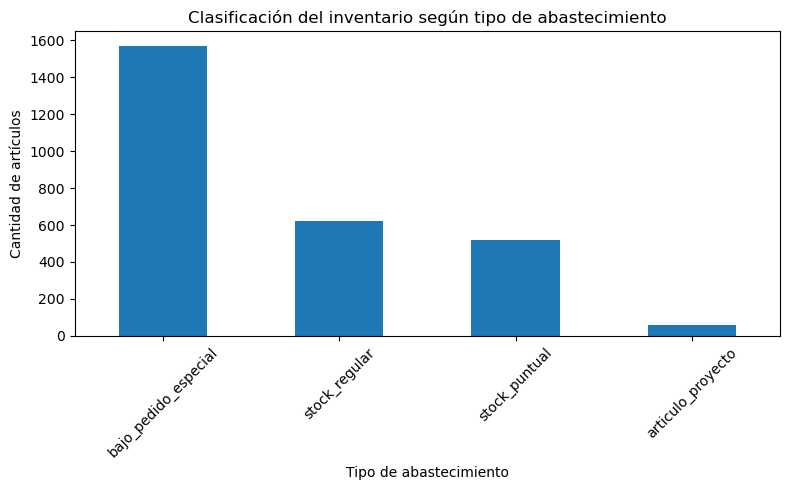

In [51]:
import matplotlib.pyplot as plt

conteo_abastecimiento = df_OITM_Ventas["tipo_abastecimiento"].value_counts()

plt.figure(figsize=(8, 5))
conteo_abastecimiento.plot(kind="bar")

plt.title("Clasificación del inventario según tipo de abastecimiento")
plt.xlabel("Tipo de abastecimiento")
plt.ylabel("Cantidad de artículos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

    Tipo_Abastecimiento  Cantidad_Articulos  Porcentaje
0  bajo_pedido_especial                1571       56.65
1         stock_regular                 624       22.50
2         stock_puntual                 520       18.75
3     articulo_proyecto                  58        2.09


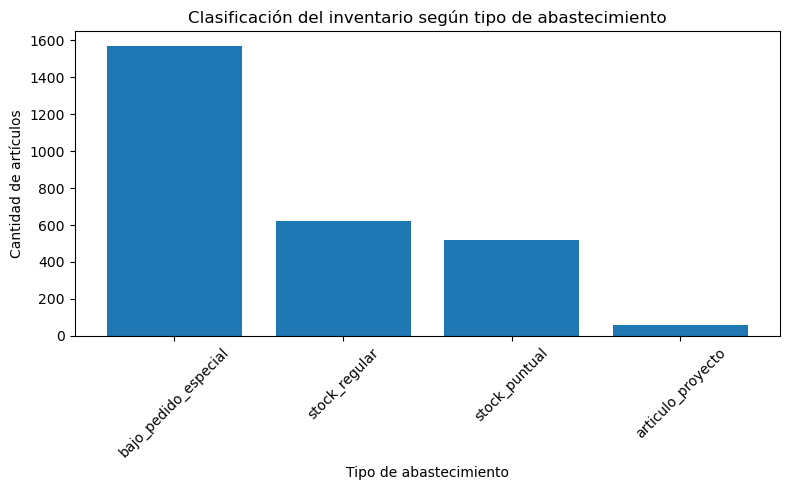

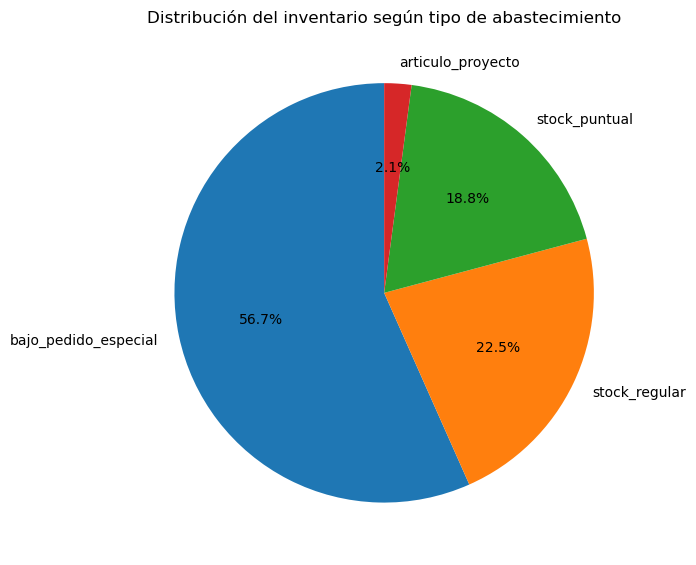

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# RESUMEN DE CLASIFICACIÓN DE ABASTECIMIENTO
# ============================================

resumen_abastecimiento = df_OITM_Ventas["tipo_abastecimiento"].value_counts().reset_index()
resumen_abastecimiento.columns = ["Tipo_Abastecimiento", "Cantidad_Articulos"]

resumen_abastecimiento["Porcentaje"] = (
    resumen_abastecimiento["Cantidad_Articulos"]
    / resumen_abastecimiento["Cantidad_Articulos"].sum()
    * 100
).round(2)

print(resumen_abastecimiento)

# ============================================
# GRÁFICO DE BARRAS
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(
    resumen_abastecimiento["Tipo_Abastecimiento"],
    resumen_abastecimiento["Cantidad_Articulos"]
)

plt.title("Clasificación del inventario según tipo de abastecimiento")
plt.xlabel("Tipo de abastecimiento")
plt.ylabel("Cantidad de artículos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================
# DIAGRAMA DE PASTEL
# ============================================

plt.figure(figsize=(7, 7))

plt.pie(
    resumen_abastecimiento["Cantidad_Articulos"],
    labels=resumen_abastecimiento["Tipo_Abastecimiento"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribución del inventario según tipo de abastecimiento")
plt.tight_layout()
plt.show()

In [53]:
df_OITM_Ventas["tipo_abastecimiento"].value_counts(normalize=True)*100



tipo_abastecimiento
bajo_pedido_especial    56.653444
stock_regular           22.502705
stock_puntual           18.752254
articulo_proyecto        2.091598
Name: proportion, dtype: float64

In [54]:
df_OITM_Ventas_filtrado = df_OITM_Ventas[df_OITM_Ventas["tipo_abastecimiento"] == "Stock puntual"].copy()
df_OITM_Ventas_filtrado.sort_values(by="meses_con_venta_24m", ascending=True)

,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,unidad_medida_inventario,marca_fabricante,ultima_fecha_compra,ultimo_precio_compra,...,venta_proyecto,ciclo_vida,cantidad_vendida_24m,precio_referencia,venta_estimada_24m,participacion_comercial,participacion_acumulada,criticidad_comercial,meses_con_venta_24m,frecuencia_venta_24m_pct


In [55]:
df_OITM_Ventas_filtrado["meses_con_venta_24m"].value_counts()

Series([], Name: count, dtype: int64)

In [56]:
df_OITM_Ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 2773 entries, 0 to 2772
Columns: 102 entries, codigo_articulo to frecuencia_venta_24m_pct
dtypes: datetime64[us](2), float64(64), int64(6), object(12), str(18)
memory usage: 2.8+ MB


## Introducción

En este procedimiento se define una regla de negocio para determinar si un artículo debe ser considerado dentro del proceso de forecast o pronóstico de demanda.

No todos los artículos del inventario deben proyectarse con modelos de demanda, ya que algunos productos no responden a un comportamiento regular de consumo. En particular, los artículos clasificados como **Artículo de Proyecto** o **Bajo Pedido Especial** no deben aplicar a forecast, debido a que su compra y venta dependen de necesidades puntuales, proyectos específicos o solicitudes especiales de clientes.

Por esta razón, se crea una nueva variable llamada **Aplica_Forecast**, la cual permite identificar de forma clara si un artículo debe incluirse o excluirse del análisis de pronóstico.

La lógica utilizada es la siguiente:

- Si el artículo está clasificado como **Artículo de Proyecto**, entonces **no aplica forecast**.
- Si el artículo está clasificado como **Bajo Pedido Especial**, entonces **no aplica forecast**.
- Para el resto de clasificaciones, el artículo **sí aplica forecast**.

Esta clasificación permite separar los artículos con demanda regular de aquellos que deben manejarse bajo criterios comerciales o de abastecimiento específicos. De esta manera, el modelo de reabastecimiento evita generar recomendaciones incorrectas sobre artículos que no deberían ser proyectados automáticamente.

In [57]:
df_OITM_Ventas["tipo_abastecimiento"].value_counts()

tipo_abastecimiento
bajo_pedido_especial    1571
stock_regular            624
stock_puntual            520
articulo_proyecto         58
Name: count, dtype: int64

In [58]:
df_OITM_Ventas["aplica_forecast"] = ~ df_OITM_Ventas["tipo_abastecimiento"].isin([
    "articulo_proyecto",
    "bajo_pedido_especial"
]).copy()

In [59]:
lista_columnas_filtro=["tipo_abastecimiento", "aplica_forecast"]

In [60]:
df_OITM_Ventas[lista_columnas_filtro].value_counts()

tipo_abastecimiento   aplica_forecast
bajo_pedido_especial  False              1571
stock_regular         True                624
stock_puntual         True                520
articulo_proyecto     False                58
Name: count, dtype: int64

# Procedimiento: Cálculo de Alcance de Inventario 24M

## Objetivo

Calcular una nueva columna en el dataframe `df_oitm_Ventas` llamada:

```python
alcance_inventario_24m

#inputar dataframe en base de datos render

In [61]:
import numpy as np
import pandas as pd

# Asegurar formato fecha
df_OITM_Ventas["ultima_fecha_compra"] = pd.to_datetime(
    df_OITM_Ventas["ultima_fecha_compra"],
    errors="coerce"
)

# Fecha corte 12 meses
fecha_corte_12m = pd.Timestamp.today() - pd.DateOffset(months=12)

# Asegurar columnas numéricas
df_OITM_Ventas["total_unidades_vendidas_24m"] = pd.to_numeric(
    df_OITM_Ventas["total_unidades_vendidas_24m"],
    errors="coerce"
).fillna(0)

df_OITM_Ventas["stock_en_mano"] = pd.to_numeric(
    df_OITM_Ventas["stock_en_mano"],
    errors="coerce"
).fillna(0)

# Venta promedio mensual 24M
df_OITM_Ventas["venta_promedio_mensual_24m"] = (
    df_OITM_Ventas["total_unidades_vendidas_24m"] / 24
)

# Crear columnas finales
df_OITM_Ventas["alcance_inventario_24m"] = np.nan
df_OITM_Ventas["clasificacion_alcance_inventario_24m"] = ""

# Máscaras con venta
mask_con_venta = df_OITM_Ventas["total_unidades_vendidas_24m"] > 0

# Máscaras con infinito nuevo
mask_infinito_nuevo = (
    (df_OITM_Ventas["total_unidades_vendidas_24m"] == 0) &
    (df_OITM_Ventas["ultima_fecha_compra"] >= fecha_corte_12m)
)

# Máscara con infinito
mask_infinito = (
    (df_OITM_Ventas["total_unidades_vendidas_24m"] == 0) &
    (
        (df_OITM_Ventas["ultima_fecha_compra"] < fecha_corte_12m) |
        (df_OITM_Ventas["ultima_fecha_compra"].isna())
    )
)


# Caso 1: artículos con venta se calcula el alcance_inventario_24m
df_OITM_Ventas.loc[mask_con_venta, "alcance_inventario_24m"] = (
    df_OITM_Ventas.loc[mask_con_venta, "stock_en_mano"] /
    df_OITM_Ventas.loc[mask_con_venta, "venta_promedio_mensual_24m"]
)

# Clasificacion de alcance_inventario_24m = Normal para articulos con venta
df_OITM_Ventas.loc[
    mask_con_venta,
    "clasificacion_alcance_inventario_24m"
] = "Normal"

# Caso 2: sin venta, pero compra reciente, "alcance_inventario_24m" tiende a infinito
df_OITM_Ventas.loc[
    mask_infinito_nuevo,
    "alcance_inventario_24m"
] = np.inf

# Caso 2: Clasificacion para infinito nuevo
df_OITM_Ventas.loc[
    mask_infinito_nuevo,
    "clasificacion_alcance_inventario_24m"
] = "Infinito nuevo"

# Caso 3: sin venta, y sin compra reciente, "alcance_inventario_24m" tiende a infinito
df_OITM_Ventas.loc[
    mask_infinito,
    "alcance_inventario_24m"
] = np.inf

# Caso 3: Clasificacion para infinito
df_OITM_Ventas.loc[
    mask_infinito,
    "clasificacion_alcance_inventario_24m"
] = "Infinito"

# Cálculo de Stock Mínimo, Stock Máximo y Punto de Reorden

## Objetivo

Definir una metodología en pandas para calcular, por cada artículo del dataframe `df_OITM_Ventas`, los niveles recomendados de inventario que permitan responder tres preguntas principales:

1. ¿Cuándo debo hacer un pedido?
2. ¿Cuánto debo pedir?
3. ¿Vale la pena comprar este artículo o no?

Este cálculo busca apoyar la toma de decisiones de reabastecimiento usando variables históricas de venta, inventario disponible, lead time y frecuencia de compra.

---

## Idea principal

Para decidir si un artículo debe comprarse, no basta con ver solamente el stock actual.

Se deben considerar también:

```text
stock actual
stock comprometido
stock en tránsito
venta promedio mensual
lead time promedio
meses promedio entre compras
clasificación del alcance de inventario

In [62]:
import numpy as np
import pandas as pd

# ============================================================
# 1. ASEGURAR COLUMNAS NUMÉRICAS
# ============================================================

columnas_numericas = [
    "stock_en_mano",
    "stock_comprometido",
    "stock_en_pedido_transito",
    "total_unidades_vendidas_24m",
    "lead_time_promedio_dias",
    "meses_promedio_entre_compras_24m"
]

for col in columnas_numericas:
    df_OITM_Ventas[col] = pd.to_numeric(
        df_OITM_Ventas[col],
        errors="coerce"
    ).fillna(0)


# ============================================================
# 2. STOCK DISPONIBLE PROYECTADO
# ============================================================

df_OITM_Ventas["stock_disponible_proyectado"] = (
    df_OITM_Ventas["stock_en_mano"]
    - df_OITM_Ventas["stock_comprometido"]
    + df_OITM_Ventas["stock_en_pedido_transito"]
)


# ============================================================
# 3. VENTA PROMEDIO MENSUAL 24M
# ============================================================

df_OITM_Ventas["venta_promedio_mensual_24m"] = (
    df_OITM_Ventas["total_unidades_vendidas_24m"] / 24
)


# ============================================================
# 4. LEAD TIME EN MESES
# ============================================================

df_OITM_Ventas["lead_time_meses"] = (
    df_OITM_Ventas["lead_time_promedio_dias"] / 30
)


# ============================================================
# 5. FACTOR DE SEGURIDAD EN MESES
# ============================================================
# Regla inicial sugerida:2 semanas = 0.5 mes

df_OITM_Ventas["factor_seguridad_meses"] = 0.5


# ============================================================
# 6. STOCK DE SEGURIDAD
# ============================================================

df_OITM_Ventas["stock_seguridad"] = (
    df_OITM_Ventas["venta_promedio_mensual_24m"]
    * df_OITM_Ventas["factor_seguridad_meses"]
)


# ============================================================
# 7. STOCK MÍNIMO
# ============================================================
# Stock mínimo = demanda esperada durante el lead time

df_OITM_Ventas["stock_minimo"] = (
    df_OITM_Ventas["venta_promedio_mensual_24m"]
    * df_OITM_Ventas["lead_time_meses"]
)


# ============================================================
# 8. PUNTO DE REORDEN
# ============================================================
# Punto de reorden = stock mínimo + stock de seguridad

df_OITM_Ventas["punto_stock_reorden"] = (
    df_OITM_Ventas["stock_minimo"]
    + df_OITM_Ventas["stock_seguridad"]
)


# Parametrización de Meses Objetivo de Cobertura por Fabricante

## Objetivo

Asignar la columna `meses_objetivo_cobertura` al dataframe `df_OITM_Ventas` usando una tabla externa en Excel parametrizada por `marca_fabricante`.

Esto permite definir cuántos meses de cobertura objetivo debe manejar cada marca o fabricante, en lugar de calcularlo únicamente con base en el histórico de compras.

---

## Idea principal

La lógica consiste en cruzar el dataframe principal de artículos con un archivo Excel de parámetros.

```text
df_OITM_Ventas
+
Excel de parámetros por fabricante
=
df_OITM_Ventas con meses_objetivo_cobertura

In [63]:
import pandas as pd
import numpy as np

# ============================================================
# 1. LEER ARCHIVO EXCEL DE PARÁMETROS POR FABRICANTE
# ============================================================

df_periodos_reabastecimiento_por_fabricante= pd.read_excel(
    ruta_fabricantes
)


# ============================================================
# 2. NORMALIZAR MARCA FABRICANTE EN AMBOS DATAFRAMES
# ============================================================

df_OITM_Ventas["marca_fabricante_normalizada"] = (
    df_OITM_Ventas["marca_fabricante"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_periodos_reabastecimiento_por_fabricante["marca_fabricante_normalizada"] = (
    df_periodos_reabastecimiento_por_fabricante["marca_fabricante"]
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 3. ASEGURAR QUE MESES OBJETIVO COBERTURA SEA NUMÉRICO
# ============================================================

df_periodos_reabastecimiento_por_fabricante["meses_objetivo_cobertura"] = pd.to_numeric(
    df_periodos_reabastecimiento_por_fabricante["meses_objetivo_cobertura"],
    errors="coerce"        
    ).fillna(0)


# ============================================================
# 4. CRUZAR PARÁMETROS CON DATAFRAME PRINCIPAL
# ============================================================

df_OITM_Ventas = df_OITM_Ventas.merge(
    df_periodos_reabastecimiento_por_fabricante[
        ["marca_fabricante_normalizada", "meses_objetivo_cobertura"]
    ],
    on="marca_fabricante_normalizada",
    how="left",
)


# ============================================================
# 5. IDENTIFICAR MARCAS SIN PARÁMETRO
# ============================================================

df_OITM_Ventas["requiere_revision_parametro_cobertura"] = (
    df_OITM_Ventas["meses_objetivo_cobertura"].isna()
)

df_OITM_Ventas = df_OITM_Ventas.rename(columns={
    "meses_objetivo_cobertura_merge": "meses_objetivo_cobertura"
})

# ============================================================
# 6. ASIGNAR VALOR POR DEFECTO SI NO EXISTE PARÁMETRO
# ============================================================

df_OITM_Ventas["meses_objetivo_cobertura"] = (
    df_OITM_Ventas["meses_objetivo_cobertura"]
    .fillna(0)
)


# ============================================================
# 7. REVISAR MARCAS SIN PARÁMETRO
# ============================================================

df_marcas_sin_parametro = df_OITM_Ventas[
    df_OITM_Ventas["requiere_revision_parametro_cobertura"]
][["marca_fabricante"]].drop_duplicates().sort_values("marca_fabricante")

print(df_marcas_sin_parametro.to_string(index=False))

Empty DataFrame
Columns: [marca_fabricante]
Index: []


In [64]:

df_OITM_Ventas["meses_objetivo_cobertura"].value_counts()
      

meses_objetivo_cobertura
6.0    2773
Name: count, dtype: int64

In [65]:
df_OITM_Ventas["punto_stock_reorden"].isna().value_counts()

punto_stock_reorden
False    2773
Name: count, dtype: int64

In [66]:

#============================================================
# 9. MESES OBJETIVO DE COBERTURA
# ============================================================
# Se usa meses_promedio_entre_compras_24m, pero limitado
# para evitar coberturas exageradas.

# df_OITM_Ventas["meses_objetivo_cobertura"] = (
#     df_OITM_Ventas["meses_promedio_entre_compras_24m"]
#     .clip(lower=1, upper=6)
# )

# Si no tuvo ventas, no se recomienda cobertura automática.
df_OITM_Ventas.loc[
    df_OITM_Ventas["venta_promedio_mensual_24m"] == 0,
    "meses_objetivo_cobertura"
] = 0


# ============================================================
# 10. STOCK MÁXIMO
# ============================================================
# Stock máximo = demanda mensual × meses totales objetivo

df_OITM_Ventas["stock_maximo"] = (
    df_OITM_Ventas["venta_promedio_mensual_24m"]
    * (
        + df_OITM_Ventas["meses_objetivo_cobertura"]
        + df_OITM_Ventas["factor_seguridad_meses"]
    )
)


# ============================================================
# 11. CANTIDAD SUGERIDA A PEDIR
# ============================================================

df_OITM_Ventas["cantidad_sugerida_pedir"] = np.where(
    df_OITM_Ventas["stock_disponible_proyectado"] <= df_OITM_Ventas["punto_stock_reorden"],
    df_OITM_Ventas["stock_maximo"] - df_OITM_Ventas["stock_disponible_proyectado"],
    0
)

# Evitar cantidades negativas.
df_OITM_Ventas["cantidad_sugerida_pedir"] = (
    df_OITM_Ventas["cantidad_sugerida_pedir"]
    .clip(lower=0)
)


# ============================================================
# 12. MESES HASTA REORDEN
# ============================================================

df_OITM_Ventas["meses_hasta_reorden"] = np.where(
    df_OITM_Ventas["venta_promedio_mensual_24m"] > 0,
    (
        df_OITM_Ventas["stock_disponible_proyectado"]
        - df_OITM_Ventas["punto_stock_reorden"]
    ) / df_OITM_Ventas["venta_promedio_mensual_24m"],
    np.inf
)




In [67]:

# ============================================================
# 13. DECISIÓN DE COMPRA
# ============================================================

umbral_revision_compra_meses = 2

df_OITM_Ventas["decision_compra"] = np.select(
    [
        # 1. Sin venta en los últimos 24 meses
        df_OITM_Ventas["venta_promedio_mensual_24m"] == 0,

        # 2. Sin stock disponible proyectado
        df_OITM_Ventas["stock_disponible_proyectado"] <= 0,

        # 3. Ya llegó o está por debajo del punto de reorden
        df_OITM_Ventas["stock_disponible_proyectado"] <= df_OITM_Ventas["punto_stock_reorden"],

        # 4. Está cerca del punto de reorden y vale la pena evaluarlo
        (
            (df_OITM_Ventas["stock_disponible_proyectado"] > df_OITM_Ventas["punto_stock_reorden"]) &
            (df_OITM_Ventas["meses_hasta_reorden"] > 0) &
            (df_OITM_Ventas["meses_hasta_reorden"] <= umbral_revision_compra_meses)
        ),

        # 5. Sobreinventario
        df_OITM_Ventas["alcance_inventario_24m"] > (
            df_OITM_Ventas["meses_objetivo_cobertura"]
            + df_OITM_Ventas["factor_seguridad_meses"]
        )
    ],
    [
        "No comprar - sin venta 24M",
        "Comprar urgente - sin stock disponible",
        "Comprar urgente - stock mínimo alcanzado",
        "Evaluar compra - próximo a punto de reorden",
        "No comprar - sobreinventario"
    ],
    default="No comprar todavía"
    
    )

# Priorización de Revisión de Stock por Fabricante

## Objetivo

Crear una metodología para identificar **con qué fabricante o proveedor conviene iniciar la revisión de stock**, considerando el valor económico de los artículos que podrían requerir compra.

La finalidad no es solamente detectar artículos que ya llegaron al punto de reorden, sino también identificar proveedores que tienen artículos cercanos a llegar a ese umbral y que representan un valor importante en ventas.

---

## Idea principal

Los pedidos normalmente se gestionan por fabricante o proveedor.  
Por eso, además de analizar artículo por artículo, se necesita una vista agrupada por `marca_fabricante`.

La pregunta principal es:

```text
¿Qué fabricante concentra mayor riesgo económico de abastecimiento?

In [68]:
import numpy as np
import pandas as pd

# ============================================================
# PRIORIZACIÓN DE REVISIÓN DE STOCK POR FABRICANTE
# ============================================================
# Objetivo:
# Crear una métrica económica que permita identificar con qué
# fabricante/proveedor conviene iniciar la revisión de stock.
#
# La lógica considera:
# - Valor mensual de venta por artículo.
# - Artículos ya por debajo del punto de reorden.
# - Artículos próximos a llegar al punto de reorden.
# - Monto económico inmediato en riesgo.
# - Monto económico próximo en riesgo.
# - Score consolidado por fabricante.
# ============================================================


# ============================================================
# 1. CONFIGURACIÓN GENERAL
# ============================================================

# Ventana de análisis para artículos próximos al punto de reorden.
# Ejemplo: 2 significa que se evaluarán artículos que llegarán al
# punto de reorden dentro de los próximos 3 meses.
ventana_revision_compra_meses = 3

# Columna de precio que se usará para valorizar la venta mensual
# y el riesgo económico.
# Ajustar este nombre según la columna real de tu dataframe.
df_OITM_Ventas["precio_referencia"]=df_OITM_Ventas["ultimo_precio_compra"]*1.35
columna_precio="precio_referencia"


# ============================================================
# 2. ASEGURAR COLUMNAS NUMÉRICAS
# ============================================================
# Estas columnas se usarán en operaciones matemáticas.
# Se convierten a numérico para evitar errores por textos, vacíos
# o valores inválidos.
#
# errors="coerce":
#   convierte valores no numéricos en NaN.
#
# fillna(0):
#   reemplaza NaN por 0 para permitir los cálculos.
# ============================================================

columnas_numericas_prioridad = [
    "venta_promedio_mensual_24m",
    columna_precio,
    "punto_stock_reorden",
    "stock_disponible_proyectado",
    "meses_hasta_reorden"
]

for col in columnas_numericas_prioridad:
    df_OITM_Ventas[col] = pd.to_numeric(
        df_OITM_Ventas[col],
        errors="coerce"
    ).fillna(0)


# ============================================================
# 3. VALOR DE VENTA MENSUAL POR ARTÍCULO
# ============================================================
# Esta métrica estima cuánto representa cada artículo en ventas
# mensuales promedio.
#
# Fórmula:
# valor_venta_mensual_24m =
# venta_promedio_mensual_24m × precio_referencia
# ============================================================

df_OITM_Ventas["valor_venta_mensual_24m"] = (
    df_OITM_Ventas["venta_promedio_mensual_24m"]
    * df_OITM_Ventas[columna_precio]
)


# ============================================================
# 4. DÉFICIT CONTRA PUNTO DE REORDEN
# ============================================================
# Mide qué tan por debajo o por encima está el stock disponible
# proyectado respecto al punto de reorden.
#
# Fórmula:
# deficit_punto_reorden =
# "punto_stock_reorden" - stock_disponible_proyectado
#
# Interpretación:
# > 0  : ya está por debajo del punto de reorden
# = 0  : está exactamente en el punto de reorden
# < 0  : todavía está por encima del punto de reorden
# ============================================================

df_OITM_Ventas["deficit_punto_reorden"] = (
    df_OITM_Ventas["punto_stock_reorden"]
    - df_OITM_Ventas["stock_disponible_proyectado"]
)


# ============================================================
# 5. DÉFICIT POSITIVO CONTRA PUNTO DE REORDEN
# ============================================================
# Se conserva únicamente el déficit real.
# Si el artículo todavía está por encima del punto de reorden,
# el déficit se fuerza a 0.
#
# Esto evita considerar como riesgo inmediato artículos que aún
# tienen inventario suficiente.
# ============================================================

df_OITM_Ventas["deficit_punto_reorden_positivo"] = (
    df_OITM_Ventas["deficit_punto_reorden"]
    .clip(lower=0)
)


# ============================================================
# 6. MONTO DE RIESGO INMEDIATO
# ============================================================
# Cuantifica en dinero el riesgo asociado a artículos que ya están
# por debajo del punto de reorden.
#
# Fórmula:
# monto_riesgo_inmediato =
# deficit_punto_reorden_positivo × precio_referencia
#
# Esta métrica responde:
# ¿Cuánto valor económico ya está en riesgo porque el artículo
# está por debajo del punto de reorden?
# ============================================================

df_OITM_Ventas["monto_riesgo_inmediato"] = (
    df_OITM_Ventas["deficit_punto_reorden_positivo"]
    * df_OITM_Ventas[columna_precio]
)


# ============================================================
# 7. MONTO DE RIESGO PRÓXIMO
# ============================================================
# Cuantifica el riesgo económico de artículos que todavía no están
# por debajo del punto de reorden, pero que están próximos a llegar.
#
# Se consideran próximos si:
# 0 < meses_hasta_reorden <= ventana_revision_compra_meses
#
# La ponderación aumenta mientras más cercano esté el artículo
# al punto de reorden.
#
# Fórmula conceptual:
# monto_riesgo_proximo =
# valor_venta_mensual_24m × ponderación_por_cercanía
#
# ponderación_por_cercanía =
# ventana_revision_compra_meses - meses_hasta_reorden + 1
# ============================================================

df_OITM_Ventas["monto_riesgo_proximo"] = np.where(
    (
        (df_OITM_Ventas["meses_hasta_reorden"] > 0)
        & (df_OITM_Ventas["meses_hasta_reorden"] <= ventana_revision_compra_meses)
    ),
    (
        df_OITM_Ventas["valor_venta_mensual_24m"]
        * (
            ventana_revision_compra_meses
            - df_OITM_Ventas["meses_hasta_reorden"]
            + 1
        )
    ),
    0
)


# ============================================================
# 8. SCORE DE PRIORIDAD POR ARTÍCULO
# ============================================================
# Consolida el riesgo inmediato y el riesgo próximo en una sola
# métrica de prioridad.
#
# Fórmula:
# score_prioridad_articulo =
# monto_riesgo_inmediato + monto_riesgo_proximo
#
# Mientras mayor sea este score, mayor prioridad tiene el artículo
# dentro de la revisión de stock.
# ============================================================

df_OITM_Ventas["score_prioridad_articulo"] = (
    df_OITM_Ventas["monto_riesgo_inmediato"]
    + df_OITM_Ventas["monto_riesgo_proximo"]
)


# ============================================================
# 9. VENTA MENSUAL EN REVISIÓN
# ============================================================
# Identifica el valor mensual de venta asociado a artículos que
# deben ser revisados durante el análisis actual.
#
# Incluye artículos con decisión:
# - Comprar urgente - sin stock disponible
# - Comprar urgente - stock mínimo alcanzado
# - Comprar
# - Evaluar compra - próximo a punto de reorden
#
# Si el artículo no requiere revisión, se asigna 0.
# ============================================================

decisiones_en_revision = [
    "Comprar urgente - sin stock disponible",
    "Comprar urgente - stock mínimo alcanzado",
    "Comprar",
    "Evaluar compra - próximo a punto de reorden"
]

df_OITM_Ventas["venta_mensual_en_revision"] = np.where(
    df_OITM_Ventas["decision_compra"].isin(decisiones_en_revision),
    df_OITM_Ventas["valor_venta_mensual_24m"],
    0
)


# ============================================================
# 10. RESUMEN DE PRIORIDAD POR FABRICANTE
# ============================================================
# Agrupa la información por fabricante para saber con qué proveedor
# conviene iniciar la revisión.
#
# Métricas calculadas:
# - cantidad_articulos:
#     cantidad total de artículos del fabricante.
#
# - articulos_comprar:
#     artículos que ya requieren compra.
#
# - articulos_evaluar:
#     artículos próximos al punto de reorden.
#
# - venta_mensual_total:
#     venta mensual promedio total del fabricante.
#
# - venta_mensual_en_revision:
#     venta mensual asociada a artículos que requieren revisión.
#
# - monto_riesgo_inmediato:
#     monto económico de artículos bajo punto de reorden.
#
# - monto_riesgo_proximo:
#     monto económico de artículos próximos al punto de reorden.
#
# - score_prioridad_fabricante:
#     métrica total para ordenar fabricantes por prioridad.
# ============================================================

df_prioridad_fabricante = (
    df_OITM_Ventas
    .groupby("marca_fabricante", as_index=False)
    .agg(
        cantidad_articulos=("codigo_articulo", "count"),

        articulos_comprar=(
            "decision_compra",
            lambda x: x.isin([
                "Comprar urgente - sin stock disponible",
                "Comprar urgente - stock mínimo alcanzado",
                "Comprar"
            ]).sum()
        ),

        articulos_evaluar=(
            "decision_compra",
            lambda x: x.eq(
                "Evaluar compra - próximo a punto de reorden"
            ).sum()
        ),

        venta_mensual_total=("valor_venta_mensual_24m", "sum"),
        venta_mensual_en_revision=("venta_mensual_en_revision", "sum"),
        monto_riesgo_inmediato=("monto_riesgo_inmediato", "sum"),
        monto_riesgo_proximo=("monto_riesgo_proximo", "sum"),
        score_prioridad_fabricante=("score_prioridad_articulo", "sum")
    )
    .sort_values("score_prioridad_fabricante", ascending=False)
)


# ============================================================
# 11. CLASIFICACIÓN DE PRIORIDAD POR FABRICANTE
# ============================================================
# Asigna una etiqueta ejecutiva de prioridad.
#
# Los umbrales son referenciales y deben ajustarse según el tamaño
# real del negocio y los montos típicos de venta.
#
# Reglas actuales:
# score >= 10000  -> Alta
# score >= 5000   -> Media
# score > 0       -> Baja
# score = 0       -> Sin prioridad
# ============================================================

df_prioridad_fabricante["prioridad_revision_fabricante"] = np.select(
    [
        df_prioridad_fabricante["score_prioridad_fabricante"] >= 10000,
        df_prioridad_fabricante["score_prioridad_fabricante"] >= 5000,
        df_prioridad_fabricante["score_prioridad_fabricante"] > 1000
    ],
    [
        "Alta",
        "Media",
        "Baja"
    ],
    default="Sin prioridad"
)


# ============================================================
# 12. ORDEN FINAL DEL RESUMEN
# ============================================================
# Se ordena nuevamente para asegurar que los fabricantes con mayor
# prioridad económica aparezcan primero.
# ============================================================

df_prioridad_fabricante = df_prioridad_fabricante.sort_values(
    by="score_prioridad_fabricante",
    ascending=False
).reset_index(drop=True)


# ============================================================
# 13. VISTA DETALLADA OPCIONAL POR ARTÍCULO
# ============================================================
# Esta tabla sirve para revisar artículo por artículo, ordenado por
# prioridad económica.
#
# Permite entender qué artículos explican la prioridad de cada
# fabricante.
# ============================================================

columnas_revision_articulo = [
    "codigo_articulo",
    "descripcion_completa",
    "marca_fabricante",
    "stock_disponible_proyectado",
    "punto_stock_reorden",
    "meses_hasta_reorden",
    "venta_promedio_mensual_24m",
    "valor_venta_mensual_24m",
    "deficit_punto_reorden",
    "monto_riesgo_inmediato",
    "monto_riesgo_proximo",
    "score_prioridad_articulo",
    "decision_compra"
]

df_prioridad_articulo = (
    df_OITM_Ventas[columnas_revision_articulo]
    .sort_values("score_prioridad_articulo", ascending=False)
    .reset_index(drop=True)
)


# ============================================================
# 14. VALIDACIÓN RÁPIDA DE RESULTADOS
# ============================================================
# Mostrar los fabricantes con mayor prioridad de revisión.
# ============================================================

df_prioridad_fabricante.head(20)

,marca_fabricante,cantidad_articulos,articulos_comprar,articulos_evaluar,venta_mensual_total,venta_mensual_en_revision,monto_riesgo_inmediato,monto_riesgo_proximo,score_prioridad_fabricante,prioridad_revision_fabricante
0,SIEMENS,387,10,38,38125.611488,26326.194830,910.197645,76116.717741,77026.915387,Alta
1,SHARDA,12,2,1,6729.957765,4394.861145,6254.135081,8592.020947,14846.156028,Alta
2,FLEXCO,69,4,8,7253.062437,2983.868039,2107.402030,5147.129662,7254.531692,Media
3,NTN,457,6,18,6695.840263,785.292595,822.247302,2464.957808,3287.205110,Baja
4,DODGE,85,2,6,2436.077805,804.692936,260.594327,2335.567071,2596.161398,Baja
5,BANDO,469,12,35,4609.403457,771.836666,227.134438,2131.536511,2358.670949,Baja
6,SUMITOMO,139,5,1,8572.162885,2499.136836,1423.782612,871.404074,2295.186686,Baja
7,HABASIT ABT,43,4,2,4622.548780,669.831547,38.241136,1989.282058,2027.523193,Baja
8,TSUBAKI,68,0,6,2185.388422,498.398074,0.000000,1756.394482,1756.394482,Baja
9,MARTIN,37,1,4,753.347191,394.270005,293.919208,1230.436959,1524.356167,Baja


In [69]:
import numpy as np
import pandas as pd

# ============================================================
# LIMPIEZA DE VALORES NULOS ANTES DE INSERTAR EN POSTGRESQL
# ============================================================
# Problema:
# Pandas maneja valores vacíos de diferentes maneras:
#
# - NaN  = valor vacío numérico
# - NaT  = valor vacío de fecha
# - inf  = infinito
# - -inf = infinito negativo
#
# PostgreSQL no acepta directamente NaN/NaT en columnas tipo timestamp,
# numeric, date, etc.
#
# Solución:
# Convertimos todos esos valores a None.
#
# None en Python se interpreta como NULL en PostgreSQL.
# ============================================================

df_OITM_Ventas = df_OITM_Ventas.replace([np.inf, -np.inf], np.nan)

df_OITM_Ventas = df_OITM_Ventas.astype(object).where(
    pd.notnull(df_OITM_Ventas),
    None
)

In [70]:
from sqlalchemy import create_engine
import pandas as pd

# ============================================================
# CARGAR VARIABLES DE ENTORNO
# ============================================================

load_dotenv()

PGHOST = os.getenv("PGHOST")
PGPORT = os.getenv("PGPORT", "5432")
PGDATABASE = os.getenv("PGDATABASE")
PGUSER = os.getenv("PGUSER")
PGPASSWORD = os.getenv("PGPASSWORD")

if not all([PGHOST, PGPORT, PGDATABASE, PGUSER, PGPASSWORD]):
    raise ValueError("Faltan variables de conexión en el archivo .env")
# ============================
# 1. Datos de conexión Render
# ============================

usuario=PGUSER
password=PGPASSWORD
host=PGHOST
puerto=5432
base_datos=PGDATABASE

engine = create_engine(
    f"postgresql+psycopg2://{usuario}:{password}@{host}:{puerto}/{base_datos}"
)


In [71]:
# ============================================================
# PRUEBA DE CONEXIÓN A POSTGRESQL
# ============================================================

try:
    with engine.connect() as conn:
        resultado = conn.execute(text("SELECT current_database(), current_user, NOW();"))
        fila = resultado.fetchone()

        print("Conexión exitosa a PostgreSQL")
        print(f"Base de datos: {fila[0]}")
        print(f"Usuario conectado: {fila[1]}")
        print(f"Fecha/hora servidor: {fila[2]}")

except Exception as e:
    print("Error al conectar con PostgreSQL")
    print(e)

Conexión exitosa a PostgreSQL
Base de datos: n8n_s2ji
Usuario conectado: ch7
Fecha/hora servidor: 2026-07-31 15:05:16.189407+00:00


# ============================================================
# VALIDACIÓN DE TIPOS DE DATOS Y PRECISIÓN NUMÉRICA
# ============================================================

En esta sección se valida que los valores numéricos del `DataFrame` sean compatibles con los tipos de datos definidos en la tabla de PostgreSQL.

El objetivo principal es detectar columnas que puedan generar errores al momento de insertar información en la base de datos, especialmente errores como:

```text
numeric field overflow

In [72]:
import pandas as pd
from sqlalchemy import text

# ============================================================
# 1. CONSULTAR TIPOS NUMÉRICOS DE LA TABLA EN POSTGRESQL
# ============================================================

query_tipos = """
SELECT 
    column_name,
    numeric_precision,
    numeric_scale
FROM information_schema.columns
WHERE table_schema = 'cerosa_analytics'
  AND table_name = 'oitm_ventas'
  AND data_type = 'numeric'
ORDER BY ordinal_position;
"""

df_tipos_numeric = pd.read_sql(query_tipos, engine)

df_tipos_numeric

,column_name,numeric_precision,numeric_scale
0,ultimo_precio_compra,10,2
1,costo_promedio,10,2
2,codigo_bodega,3,0
3,stock_en_mano,10,2
4,stock_comprometido,10,2
...,...,...,...
64,frecuencia_venta_24m_pct,10,4
65,valor_venta_mensual_24m,18,2
66,monto_riesgo_inmediato,18,2
67,monto_riesgo_proximo,18,2


In [73]:
# ============================================================
# 2. VALIDAR QUÉ COLUMNAS DEL DATAFRAME EXCEDEN EL LÍMITE
# ============================================================

problemas = []

for _, row in df_tipos_numeric.iterrows():
    columna = row["column_name"]
    precision = row["numeric_precision"]
    scale = row["numeric_scale"]

    # Validar solo columnas que existan en el dataframe
    if columna not in df_OITM_Ventas.columns:
        continue

    # Límite máximo permitido por NUMERIC(p, s)
    # Ejemplo: NUMERIC(8,2) permite máximo 999999.99
    digitos_enteros = precision - scale
    limite = 10 ** digitos_enteros

    # Convertir a numérico por seguridad
    serie = pd.to_numeric(df_OITM_Ventas[columna], errors="coerce")

    max_abs = serie.abs().max()

    if pd.notna(max_abs) and max_abs >= limite:
        problemas.append({
            "columna": columna,
            "tipo_postgres": f"NUMERIC({precision},{scale})",
            "limite_maximo_permitido": limite - (10 ** -scale),
            "valor_maximo_abs_dataframe": max_abs
        })

df_problemas_numeric = pd.DataFrame(problemas)

df_problemas_numeric

""


In [74]:
# ============================================================
# 3. VER FILAS PROBLEMÁTICAS POR COLUMNA
# ============================================================

for _, row in df_problemas_numeric.iterrows():
    columna = row["columna"]
    limite = row["limite_maximo_permitido"]

    print("=" * 80)
    print(f"Columna problemática: {columna}")
    print(f"Límite permitido: {limite}")
    print("=" * 80)

    display(
        df_OITM_Ventas.loc[
            pd.to_numeric(df_OITM_Ventas[columna], errors="coerce").abs() > limite,
            ["codigo_articulo", "descripcion_completa", "marca_fabricante", columna]
        ].sort_values(by=columna, ascending=False).head(20)
    )

In [76]:
from sqlalchemy import MetaData, Table
from sqlalchemy.dialects.postgresql import insert
import pandas as pd
import numpy as np
import math

# ============================================================
# 1. CREAR COPIA DEL DATAFRAME ORIGINAL
# ============================================================
# Trabajamos sobre una copia para no alterar df_OITM_Ventas.
# ============================================================

df_insert = df_OITM_Ventas.copy()


# ============================================================
# 2. REEMPLAZAR VALORES INFINITOS POR NaN
# ============================================================
# PostgreSQL puede dar problemas si recibe inf o -inf.
# Los convertimos a NaN para luego pasarlos a None.
# ============================================================

df_insert = df_insert.replace([np.inf, -np.inf], np.nan)


# ============================================================
# 3. CREAR OBJETO METADATA
# ============================================================
# MetaData guarda información sobre la estructura de las tablas.
# ============================================================

metadata = MetaData()


# ============================================================
# 4. CARGAR LA TABLA EXISTENTE DESDE POSTGRESQL
# ============================================================
# SQLAlchemy lee la estructura real de la tabla en PostgreSQL.
# ============================================================

oitm_ventas = Table(
    "oitm_ventas",
    metadata,
    schema="cerosa_analytics",
    autoload_with=engine
)


# ============================================================
# 5. CONFIGURAR CARGA POR LOTES
# ============================================================
# En vez de mandar todo el DataFrame en un solo UPSERT,
# se divide en bloques pequeños para evitar errores como:
#
# OperationalError: SSL connection has been closed unexpectedly
#
# Puedes ajustar batch_size:
# - 100 si sigue fallando
# - 500 recomendado para empezar
# - 1000 si la conexión es estable
# ============================================================

batch_size = 500

total_filas = len(df_insert)
total_lotes = math.ceil(total_filas / batch_size)

print(f"Total de filas a cargar: {total_filas}")
print(f"Tamaño de lote: {batch_size}")
print(f"Total de lotes: {total_lotes}")


# ============================================================
# 6. EJECUTAR UPSERT POR LOTES
# ============================================================
# Cada lote:
# 1. Se convierte a lista de diccionarios.
# 2. Convierte NaN, NaT y pd.NA a None.
# 3. Construye un INSERT.
# 4. Lo convierte en UPSERT con ON CONFLICT.
# 5. Lo ejecuta dentro de una transacción independiente.
# ============================================================

for i in range(total_lotes):

    # ------------------------------------------------------------
    # 6.1 Seleccionar lote del DataFrame
    # ------------------------------------------------------------

    inicio = i * batch_size
    fin = inicio + batch_size

    df_lote = df_insert.iloc[inicio:fin].copy()

    print(
        f"Cargando lote {i + 1}/{total_lotes} | "
        f"Filas {inicio} a {min(fin, total_filas)} | "
        f"Registros: {len(df_lote)}"
    )

    # ------------------------------------------------------------
    # 6.2 Convertir lote a lista de diccionarios
    # ------------------------------------------------------------
    # Cada fila del DataFrame se convierte en un diccionario.
    # ------------------------------------------------------------

    data_lote = df_lote.to_dict(orient="records")

    # ------------------------------------------------------------
    # 6.3 Convertir NaN, NaT y pd.NA a None
    # ------------------------------------------------------------
    # PostgreSQL entiende None como NULL.
    # Esto evita errores como:
    # invalid input syntax for type timestamp: "NaT"
    # ------------------------------------------------------------

    data_lote = [
        {
            columna: None if pd.isna(valor) else valor
            for columna, valor in fila.items()
        }
        for fila in data_lote
    ]

    # ------------------------------------------------------------
    # 6.4 Crear INSERT base del lote
    # ------------------------------------------------------------

    stmt = insert(oitm_ventas).values(data_lote)

    # ------------------------------------------------------------
    # 6.5 Definir columnas que se actualizan si existe conflicto
    # ------------------------------------------------------------
    # Se excluye codigo_articulo porque es la PRIMARY KEY.
    # ------------------------------------------------------------

    update_columns = {
        col.name: stmt.excluded[col.name]
        for col in oitm_ventas.columns
        if col.name != "codigo_articulo"
    }

    # ------------------------------------------------------------
    # 6.6 Crear UPSERT
    # ------------------------------------------------------------

    upsert_stmt = stmt.on_conflict_do_update(
        index_elements=["codigo_articulo"],
        set_=update_columns
    )

    # ------------------------------------------------------------
    # 6.7 Ejecutar UPSERT del lote
    # ------------------------------------------------------------
    # Cada lote corre en su propia transacción.
    # Si falla, sabrás exactamente en qué lote ocurrió.
    # ------------------------------------------------------------

    try:
        with engine.begin() as conn:
            conn.execute(upsert_stmt)

    except Exception as e:
        print("=" * 80)
        print(f"ERROR EN LOTE {i + 1}/{total_lotes}")
        print(f"Rango de filas: {inicio} a {min(fin, total_filas)}")
        print("=" * 80)

        if "codigo_articulo" in df_lote.columns:
            print("Primeros códigos del lote:")
            print(df_lote["codigo_articulo"].head(10).tolist())

            print("Últimos códigos del lote:")
            print(df_lote["codigo_articulo"].tail(10).tolist())

        raise 


# ============================================================
# 7. MENSAJE FINAL DE CONFIRMACIÓN
# ============================================================

print("Tabla cerosa_analytics.oitm_ventas insertada/actualizada correctamente")

Total de filas a cargar: 2773
Tamaño de lote: 500
Total de lotes: 6
Cargando lote 1/6 | Filas 0 a 500 | Registros: 500
Cargando lote 2/6 | Filas 500 a 1000 | Registros: 500
Cargando lote 3/6 | Filas 1000 a 1500 | Registros: 500
Cargando lote 4/6 | Filas 1500 a 2000 | Registros: 500
Cargando lote 5/6 | Filas 2000 a 2500 | Registros: 500
Cargando lote 6/6 | Filas 2500 a 2773 | Registros: 273
Tabla cerosa_analytics.oitm_ventas insertada/actualizada correctamente


In [ ]:
query = """
SELECT *
FROM cerosa_analytics.oitm_ventas
LIMIT 10;
"""

pd.read_sql(query, engine)

,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,unidad_medida_inventario,marca_fabricante,ultima_fecha_compra,ultimo_precio_compra,...,requiere_revision_parametro_cobertura,valor_venta_mensual_24m,deficit_punto_reorden,deficit_punto_reorden_positivo,monto_riesgo_inmediato,monto_riesgo_proximo,score_prioridad_articulo,venta_mensual_en_revision,punto_stock_reorden,venta_julio_2026
0,TF33 35MMX66970MM,"Correa de transmisión de potencia, Habasit, TF-33",FAJAS,NaN,NaN,NaN,UNI,HABASIT ROCUA,2025-11-28,1086.08,...,False,977.47,-11.666667,0.0,0.0,0.0,0.0,0.0,0.333333,0.0
1,PX80TL-010604,Masa de acople TL 2012 Taper Lock,ACOPLES,CADENAS & SPROCKETS,SPROCKETS,SPROCKETS,UNI,DODGE,2021-05-28,84.12,...,False,0.00,-11.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,PX50TL-010601,MASA DE ACOPLE TAPER LOCK 1108,ACOPLES,CADENAS & SPROCKETS,SPROCKETS,SPROCKETS,UNI,DODGE,2021-02-08,32.60,...,False,0.00,-1.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,2/B173,Faja trapezoidal,FAJAS,CORREAS,TRAPEZOIDALES,ESTANDAR,UNI,JASON,2020-10-23,41.28,...,False,0.00,-2.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
4,2/B120,Faja trapezoidal,FAJAS,CORREAS,TRAPEZOIDALES,ESTANDAR,UNI,JASON,2020-10-23,28.70,...,False,0.00,-1.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
5,A7B93000749012,"Siemens Low Voltage, sobretens. linea de dispo...",EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,OTROS,SUPRESORES DE TRANSIENTES,UNI,SIEMENS,2023-09-14,279.56,...,False,0.00,-2.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
6,67002RS,Balero,BALEROS,NaN,NaN,NaN,UNI,INA,2026-05-21,5.00,...,False,0.00,-20.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
7,6302C3-INA,Balero,BALEROS,NaN,NaN,NaN,UNI,INA,2021-07-06,1.73,...,False,0.00,-1.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
8,630002RS,Balero 102612,BALEROS,NaN,NaN,NaN,UNI,INA,2021-10-30,8.02,...,False,0.00,-6.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
9,62152RSC3,"Rodamiento rigido de bolas, 6215LLU, Diametro ...",BALEROS,Rodamientos,Bolas,RIGIDO DE BOLAS,UNI,NTN,2025-03-14,33.85,...,False,1.90,-1.979167,0.0,0.0,0.0,0.0,0.0,0.020833,0.0


In [ ]:
anio_inicio = fecha_inicio_visual.year
anio_fin = fecha_fin.year

nombre_archivo_final = f"./Datos/dataframe_preprocesado_campos_completos_ventas_{anio_inicio}_{anio_fin}.csv"

In [ ]:
from datetime import datetime

fecha_hoy = datetime.today().strftime("%Y-%m-%d")

nombre_archivo = f"dataframe_aplica_forecast_true_{fecha_hoy}.csv"

print(nombre_archivo)

dataframe_aplica_forecast_true_2026-07-17.csv


In [ ]:
df_OITM_Ventas.to_csv(nombre_archivo_final,
    index=False,
    encoding="utf-8-sig",
    sep=";"
)

In [ ]:
query_cristian="""
SELECT
    T0."DocNum"        AS numero_factura,
    T0."DocDate"       AS fecha_factura,
    T0."CardCode"      AS codigo_cliente,
    T0."CardName"      AS nombre_cliente,
    T2."SlpName"       AS vendedor,
    T0."DocTotal"      AS total_factura,
    T0."VatSum"        AS impuesto,
    T0."DocCur"        AS moneda,
    T0."Comments"      AS comentarios
FROM OINV T0
INNER JOIN OSLP T2
    ON T0."SlpCode" = T2."SlpCode"
WHERE
    T0."CANCELED" = 'N'
    AND T2."SlpName" LIKE '%Cristian Cruz%'
    AND T0."DocDate" >= '2026-06-01'
ORDER BY
    T0."DocDate" ASC,
    T0."DocNum" ASC;
"""

In [ ]:
import pandas as pd
# 🔥 TEST 2: traer datos a pandas
query = "SELECT TOP 10 * FROM OITM"

df = pd.read_sql(query, engine)

df.head(5)

In [ ]:

df_cristian_cruz = pd.read_sql(query_cristian, engine)

df_cristian_cruz

,numero_factura,fecha_factura,codigo_cliente,nombre_cliente,vendedor,total_factura,impuesto,moneda,comentarios
0,10001434,2026-06-09,CEC000109,MARIO LARREYNAGA,32 - Cristian Cruz,655.4000,75.4000,USD,Basado en Pedidos de cliente 60000826.
1,12015910,2026-06-10,CEC000112,"DESCREM, S.A.S DE C.V",32 - Cristian Cruz,24.6905,2.8405,USD,Basado en Pedidos de cliente 60000829.
2,14002308,2026-06-11,CNA6825,"PETTENATI CENTRO AMERICA, S.A. DE C.V.",32 - Cristian Cruz,214.8400,0.0000,USD,Basado en Pedidos de cliente 60000832.
3,12015980,2026-06-12,CNA0558,LACTEOS DEL CORRAL S.A. DE C.V.,32 - Cristian Cruz,201.6000,23.4000,USD,Basado en Pedidos de cliente 60000838.
4,14002319,2026-06-12,CNA6825,"PETTENATI CENTRO AMERICA, S.A. DE C.V.",32 - Cristian Cruz,210.0000,0.0000,USD,Basado en Pedidos de cliente 60000837.
5,12016056,2026-06-18,CNA0558,LACTEOS DEL CORRAL S.A. DE C.V.,32 - Cristian Cruz,1315.5408,152.6967,USD,"parcial*--Buenas tardes, solicito de su ayuda ..."
6,12016243,2026-06-24,CNA0123,ALAS DORADAS S.A. DE C.V.,32 - Cristian Cruz,426.7200,49.5300,USD,Basado en Pedidos de cliente 60000853.\r\rGC: ...
7,12016299,2026-06-26,ECN0730,PRODUCTOS ALIMENTICIOS BOCADELI S.A. DE C.V.,32 - Cristian Cruz,405.6864,47.0886,USD,Basado en Pedidos de cliente 121750.
8,12016300,2026-06-26,ECN0730,PRODUCTOS ALIMENTICIOS BOCADELI S.A. DE C.V.,32 - Cristian Cruz,218.1760,25.3240,USD,Basado en Pedidos de cliente 121751.
9,14002366,2026-06-26,CNA6825,"PETTENATI CENTRO AMERICA, S.A. DE C.V.",32 - Cristian Cruz,107.4200,0.0000,USD,Me ayuda a facturar pero revisando que la line...


In [ ]:
df_cristian_cruz.to_csv("facturacion.csv",
    index=False,
    encoding="utf-8-sig",
    sep=";"
)